# Solar Power Forecasting Pipeline

This notebook builds a publication-grade solar forecasting workflow for an M.Tech research project using:

- Solar meter data from Google Sheets public CSV exports or the local exported Excel mirror
- NASA POWER hourly weather data
- Gradient boosting and tree baselines
- Multiple deep time-series architectures in PyTorch
- One-step and recursive multi-step evaluation

The notebook is written to be reusable, notebook-friendly, and robust to common data issues such as summary rows, missing timestamps, timezone alignment, incomplete weather coverage, and night-time zero-generation periods.

## Important note about your data source

Your shared input is a **Google Drive folder link**, not a direct Google Sheets CSV export URL.  
A Drive folder link cannot be consumed directly as a tabular CSV endpoint.

This notebook therefore supports two ingestion modes:

1. `local_xlsx`: reads the exported daily Excel files already present in this workspace
2. `google_sheets`: reads from public Google Sheets tab CSV URLs or a spreadsheet ID plus sheet names

For pure Google Sheets operation, paste a valid spreadsheet ID or direct CSV URLs in the configuration cell below.

In [32]:
# Optional one-time setup for a fresh Colab / VS Code notebook runtime
%pip install -q pandas numpy scikit-learn matplotlib requests torch openpyxl nbformat lightgbm gradio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import math
import random
import sys
import warnings
from dataclasses import dataclass
from io import StringIO
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from urllib.parse import quote, urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

CONFIG = {
    "data_source_mode": "local_xlsx",  # choose from: local_xlsx, google_sheets
    "workspace_root": Path("."),
    "local_xlsx_glob": "**/Inst_*.xlsx",
    "spreadsheet_id_or_url": None,  # set this for Google Sheets mode
    "google_sheet_tabs": ["MTR_24", "MTR_25", "MTR_26", "MTR_27", "MTR_28", "MTR_29", "Gen_Sum"],
    "google_csv_urls": {
        # Optional direct public CSV links, e.g.
        # "Gen_Sum": "https://docs.google.com/spreadsheets/d/<ID>/gviz/tq?tqx=out:csv&sheet=Gen_Sum"
    },
    "meter_tabs": ["MTR_24", "MTR_25", "MTR_26", "MTR_27", "MTR_28", "MTR_29"],
    "summary_tab": "Gen_Sum",
    "date_range": ("2025-07-14", "2026-04-12"),
    "latitude": 17.9374,
    "longitude": 79.5960,
    "timezone": "Asia/Kolkata",
    "nasa_time_standard": "LST",  # LST avoids the 30-minute UTC-to-IST shift artifact for this site
    "target_column": "power_kw",
    "frequency": "5min",
    "night_power_threshold_kw": 0.05,
    "day_irradiance_threshold": 20.0,
    "daylight_hour_window": (5.0, 19.5),
    "sequence_length": 48,  # 48 steps = 4 hours at 5-minute resolution
    "forecast_horizon_hours": 24,
    "backtest_horizon_hours": 24,
    "backtest_stride_hours": 24,
    "random_seed": 42,
    "model_names": [
        "Random Forest",
        "LightGBM",
        "CNN + LSTM",
        "PatchTST",
        "Temporal Fusion Transformer",
        "CNN + Transformer",
    ],
    "rf_param_grid": [
        {"n_estimators": 300, "max_depth": 14, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 400, "max_depth": 18, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 1, "max_features": 0.7},
    ],
    "lgbm_param_grid": [
        {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 31, "subsample": 0.9, "colsample_bytree": 0.9},
        {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 63, "subsample": 0.9, "colsample_bytree": 0.8},
    ],
    "dl_batch_size": 256,
    "dl_learning_rate": 1e-3,
    "dl_weight_decay": 1e-5,
    "dl_max_epochs": 24,
    "dl_patience": 5,
    "patch_len": 6,
    "patch_stride": 3,
    "transformer_heads": 4,
    "transformer_layers": 2,
    "transformer_d_model": 64,
    "train_fraction": 0.70,
    "val_fraction": 0.15,
}

WEATHER_COLUMNS = ["ALLSKY_SFC_SW_DWN", "T2M", "CLOUD_AMT"]
STEPS_PER_HOUR = int(pd.Timedelta("1h") / pd.Timedelta(CONFIG["frequency"]))
FORECAST_STEPS = CONFIG["forecast_horizon_hours"] * STEPS_PER_HOUR


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["random_seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

LIGHTGBM_ENABLED = HAS_LIGHTGBM and sys.version_info < (3, 14)
if HAS_LIGHTGBM and not LIGHTGBM_ENABLED:
    print("LightGBM is installed but disabled on Python 3.14 because it can crash the notebook kernel in this environment.")

Using device: cpu
LightGBM is installed but disabled on Python 3.14 because it can crash the notebook kernel in this environment.


## 1. Data ingestion

The functions below:

- read daily exported workbooks from the local mirror
- read public Google Sheets tab CSV exports
- remove summary rows such as `MIN`, `MAX`, and `AVERAGE`
- build a single clean solar generation time series
- use `Gen_Sum -> Solar Total kW` when available, otherwise sum `MTR_24` to `MTR_29`

In [2]:
def extract_spreadsheet_id(spreadsheet_id_or_url: Optional[str]) -> Optional[str]:
    if spreadsheet_id_or_url is None:
        return None
    raw = str(spreadsheet_id_or_url).strip()
    if "/spreadsheets/d/" in raw:
        return raw.split("/spreadsheets/d/")[1].split("/")[0]
    if "drive.google.com/drive/folders/" in raw:
        raise ValueError(
            "A Google Drive folder link does not expose a sheet CSV export endpoint. "
            "Please provide a spreadsheet URL/ID or direct CSV URLs for the required tabs."
        )
    return raw


def build_google_sheet_csv_url(spreadsheet_id: str, sheet_name: str) -> str:
    safe_sheet = quote(sheet_name, safe="")
    return f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/gviz/tq?tqx=out:csv&sheet={safe_sheet}"


def clean_timeseries_sheet(
    frame: pd.DataFrame,
    power_column: str,
    rename_to: str = "power_kw",
) -> pd.DataFrame:
    if "Timestamp" not in frame.columns or power_column not in frame.columns:
        return pd.DataFrame(columns=["timestamp", rename_to])

    cleaned = frame.copy()
    cleaned["timestamp"] = pd.to_datetime(cleaned["Timestamp"], errors="coerce")
    cleaned[rename_to] = pd.to_numeric(cleaned[power_column], errors="coerce")
    cleaned = cleaned.loc[cleaned["timestamp"].notna(), ["timestamp", rename_to]].copy()
    cleaned = cleaned.dropna(subset=[rename_to])
    cleaned = cleaned.drop_duplicates(subset=["timestamp"], keep="last").sort_values("timestamp")
    return cleaned.reset_index(drop=True)


def fetch_public_csv(url: str, timeout: int = 60) -> pd.DataFrame:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))


def load_google_solar_data(
    spreadsheet_id_or_url: Optional[str],
    meter_tabs: Sequence[str],
    summary_tab: str,
    csv_url_map: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    csv_url_map = csv_url_map or {}
    spreadsheet_id = extract_spreadsheet_id(spreadsheet_id_or_url)

    def get_tab_df(sheet_name: str) -> pd.DataFrame:
        if sheet_name in csv_url_map:
            return fetch_public_csv(csv_url_map[sheet_name])
        if spreadsheet_id is None:
            raise ValueError(
                f"No CSV URL provided for sheet '{sheet_name}' and no spreadsheet ID was supplied."
            )
        return fetch_public_csv(build_google_sheet_csv_url(spreadsheet_id, sheet_name))

    try:
        summary_df = get_tab_df(summary_tab)
        summary_clean = clean_timeseries_sheet(summary_df, power_column="Solar Total kW", rename_to="power_kw")
        if not summary_clean.empty:
            summary_clean["source"] = "google_sheet_summary"
            return summary_clean
    except Exception as exc:
        print(f"Summary tab fallback triggered: {exc}")

    meter_frames = []
    for tab_name in meter_tabs:
        meter_df = get_tab_df(tab_name)
        meter_clean = clean_timeseries_sheet(meter_df, power_column="kW_Total", rename_to=f"{tab_name}_power_kw")
        if not meter_clean.empty:
            meter_frames.append(meter_clean)

    if not meter_frames:
        raise ValueError("No valid solar generation data could be loaded from Google Sheets.")

    merged = meter_frames[0]
    for frame in meter_frames[1:]:
        merged = merged.merge(frame, on="timestamp", how="outer")

    meter_columns = [col for col in merged.columns if col.endswith("_power_kw")]
    merged["power_kw"] = merged[meter_columns].sum(axis=1, min_count=1)
    merged = merged.loc[:, ["timestamp", "power_kw"]].dropna().sort_values("timestamp")
    merged["source"] = "google_sheet_meter_sum"
    return merged.reset_index(drop=True)


def load_solar_from_single_workbook(
    workbook_path: Path,
    meter_tabs: Sequence[str],
    summary_tab: str,
) -> pd.DataFrame:
    excel_file = pd.ExcelFile(workbook_path)

    if summary_tab in excel_file.sheet_names:
        summary_df = excel_file.parse(summary_tab)
        summary_clean = clean_timeseries_sheet(summary_df, power_column="Solar Total kW", rename_to="power_kw")
        if not summary_clean.empty:
            summary_clean["source_file"] = workbook_path.name
            summary_clean["source"] = "local_summary"
            return summary_clean

    meter_frames = []
    for tab_name in meter_tabs:
        if tab_name not in excel_file.sheet_names:
            continue
        meter_df = excel_file.parse(tab_name)
        meter_clean = clean_timeseries_sheet(meter_df, power_column="kW_Total", rename_to=f"{tab_name}_power_kw")
        if not meter_clean.empty:
            meter_frames.append(meter_clean)

    if not meter_frames:
        return pd.DataFrame(columns=["timestamp", "power_kw", "source_file", "source"])

    merged = meter_frames[0]
    for frame in meter_frames[1:]:
        merged = merged.merge(frame, on="timestamp", how="outer")

    meter_columns = [col for col in merged.columns if col.endswith("_power_kw")]
    merged["power_kw"] = merged[meter_columns].sum(axis=1, min_count=1)
    merged = merged.loc[:, ["timestamp", "power_kw"]].dropna().sort_values("timestamp")
    merged["source_file"] = workbook_path.name
    merged["source"] = "local_meter_sum"
    return merged.reset_index(drop=True)


def finalize_solar_dataframe(
    solar_df: pd.DataFrame,
    start_date: str,
    end_date: str,
    frequency: str,
) -> pd.DataFrame:
    if solar_df.empty:
        raise ValueError("The solar dataframe is empty after ingestion.")

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date) + pd.Timedelta(days=1) - pd.Timedelta(frequency)
    solar_df = solar_df.copy()
    solar_df["timestamp"] = pd.to_datetime(solar_df["timestamp"])
    solar_df["power_kw"] = pd.to_numeric(solar_df["power_kw"], errors="coerce")
    solar_df = solar_df.dropna(subset=["timestamp", "power_kw"])
    solar_df = solar_df[(solar_df["timestamp"] >= start_ts) & (solar_df["timestamp"] <= end_ts)]
    solar_df = solar_df.drop_duplicates(subset=["timestamp"], keep="last").sort_values("timestamp")
    full_index = pd.date_range(start=solar_df["timestamp"].min(), end=solar_df["timestamp"].max(), freq=frequency)
    solar_df = solar_df.set_index("timestamp").reindex(full_index)
    solar_df.index.name = "timestamp"
    solar_df["missing_power_flag"] = solar_df["power_kw"].isna().astype(int)
    solar_df["power_kw"] = solar_df["power_kw"].interpolate(method="time", limit=2, limit_direction="both")
    solar_df["power_kw"] = solar_df["power_kw"].clip(lower=0)
    metadata_columns = [col for col in solar_df.columns if col not in {"power_kw", "missing_power_flag"}]
    for column in metadata_columns:
        solar_df[column] = solar_df[column].ffill().bfill()
    solar_df = solar_df.dropna(subset=["power_kw"]).reset_index()
    return solar_df


def load_solar_dataset(config: Dict) -> pd.DataFrame:
    mode = config["data_source_mode"]
    if mode == "google_sheets":
        solar_df = load_google_solar_data(
            spreadsheet_id_or_url=config["spreadsheet_id_or_url"],
            meter_tabs=config["meter_tabs"],
            summary_tab=config["summary_tab"],
            csv_url_map=config["google_csv_urls"],
        )
        return finalize_solar_dataframe(
            solar_df=solar_df,
            start_date=config["date_range"][0],
            end_date=config["date_range"][1],
            frequency=config["frequency"],
        )

    if mode == "local_xlsx":
        root = Path(config["workspace_root"])
        workbook_paths = sorted(root.glob(config["local_xlsx_glob"]))
        if not workbook_paths:
            raise FileNotFoundError("No local Excel workbooks matched the configured glob pattern.")

        frames = []
        for workbook_path in workbook_paths:
            frame = load_solar_from_single_workbook(
                workbook_path=workbook_path,
                meter_tabs=config["meter_tabs"],
                summary_tab=config["summary_tab"],
            )
            if not frame.empty:
                frames.append(frame)

        if not frames:
            raise ValueError("No valid local solar workbooks could be parsed.")

        solar_df = pd.concat(frames, ignore_index=True)
        return finalize_solar_dataframe(
            solar_df=solar_df,
            start_date=config["date_range"][0],
            end_date=config["date_range"][1],
            frequency=config["frequency"],
        )

    raise ValueError(f"Unsupported data_source_mode: {mode}")

## 2. NASA POWER weather enrichment

The NASA POWER hourly API is used to request:

- `ALLSKY_SFC_SW_DWN` for solar irradiance
- `T2M` for 2-meter air temperature
- `CLOUD_AMT` for cloud amount

The notebook defaults to **LST (Local Solar Time)** for NASA POWER because your site longitude is close to Indian Standard Time and LST avoids the `:30` timestamp shift that occurs when converting hourly UTC data to `Asia/Kolkata`.

In [3]:
def fetch_nasa_power_hourly(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    timezone: str,
    time_standard: str = "LST",
    parameters: Optional[Sequence[str]] = None,
) -> pd.DataFrame:
    parameters = list(parameters or WEATHER_COLUMNS)
    time_standard = str(time_standard).upper()
    base_url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    request_params = {
        "parameters": ",".join(parameters),
        "community": "RE",
        "longitude": longitude,
        "latitude": latitude,
        "start": pd.Timestamp(start_date).strftime("%Y%m%d"),
        "end": pd.Timestamp(end_date).strftime("%Y%m%d"),
        "time-standard": time_standard,
    }

    try:
        response = requests.get(
            base_url,
            params={**request_params, "format": "CSV", "header": "false"},
            timeout=120,
        )
        response.raise_for_status()
        weather = pd.read_csv(StringIO(response.text))
        required_cols = {"YEAR", "MO", "DY", "HR"}
        if not required_cols.issubset(weather.columns):
            raise ValueError("NASA CSV response did not contain the expected time columns.")

        weather = weather.rename(columns={"YEAR": "year", "MO": "month", "DY": "day", "HR": "hour"})
        weather["timestamp"] = pd.to_datetime(weather[["year", "month", "day", "hour"]])
        if time_standard == "UTC":
            weather["timestamp"] = (
                weather["timestamp"]
                .dt.tz_localize("UTC")
                .dt.tz_convert(timezone)
                .dt.tz_localize(None)
                .add(pd.Timedelta(minutes=30))
                .dt.floor("h")
            )
        weather = weather.drop(columns=["year", "month", "day", "hour"])
    except Exception as csv_error:
        print(f"CSV endpoint fallback triggered: {csv_error}")
        response = requests.get(
            base_url,
            params={**request_params, "format": "JSON"},
            timeout=120,
        )
        response.raise_for_status()
        payload = response.json()
        parameter_block = payload["properties"]["parameter"]
        timestamp_keys = sorted(next(iter(parameter_block.values())).keys())
        base_timestamp = pd.to_datetime(timestamp_keys, format="%Y%m%d%H")
        if time_standard == "UTC":
            base_timestamp = (
                base_timestamp
                .tz_localize("UTC")
                .tz_convert(timezone)
                .tz_localize(None)
                .add(pd.Timedelta(minutes=30))
                .floor("h")
            )
        weather = pd.DataFrame(
            {
                "timestamp": base_timestamp
            }
        )
        for parameter in parameters:
            weather[parameter] = [parameter_block[parameter].get(key, np.nan) for key in timestamp_keys]

    weather = weather.loc[:, ["timestamp"] + parameters].copy()
    weather = weather.set_index("timestamp").sort_index()
    for column in parameters:
        weather[column] = pd.to_numeric(weather[column], errors="coerce")
        weather[column] = weather[column].replace(-999, np.nan)

    weather = weather.interpolate(method="time", limit_direction="both")
    weather = weather.ffill().bfill()
    weather = weather[~weather.index.duplicated(keep="last")]
    weather.index.name = "timestamp"
    return weather.reset_index()


def align_weather_to_index(
    weather_hourly: pd.DataFrame,
    target_index: pd.DatetimeIndex,
) -> pd.DataFrame:
    aligned = weather_hourly.copy().set_index("timestamp").sort_index()
    aligned = aligned.reindex(aligned.index.union(target_index)).sort_index()
    aligned[WEATHER_COLUMNS] = aligned[WEATHER_COLUMNS].interpolate(method="time", limit_direction="both")
    aligned = aligned.reindex(target_index)
    aligned[WEATHER_COLUMNS] = aligned[WEATHER_COLUMNS].ffill().bfill()
    aligned.index.name = "timestamp"
    return aligned.reset_index()


def merge_solar_and_weather(solar_df: pd.DataFrame, weather_df: pd.DataFrame) -> pd.DataFrame:
    merged = solar_df.merge(weather_df, on="timestamp", how="left").sort_values("timestamp")
    for column in WEATHER_COLUMNS:
        merged[column] = pd.to_numeric(merged[column], errors="coerce")
        merged[column] = merged[column].interpolate(method="linear", limit_direction="both")
        merged[column] = merged[column].ffill().bfill()

    merged["power_kw"] = pd.to_numeric(merged["power_kw"], errors="coerce").clip(lower=0)
    merged = merged.dropna(subset=["timestamp", "power_kw"] + WEATHER_COLUMNS)
    return merged.reset_index(drop=True)

## 3. Feature engineering and time-aware splitting

We create:

- calendar features: hour, day, month, day of week, day of year
- cyclic encodings with sine and cosine transforms
- lag features: `lag_1`, `lag_24`, and an added `lag_288` for prior-day memory at 5-minute resolution
- rolling statistics from past power generation
- a daylight mask to remove night-time and near-zero generation rows from model training

In [4]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()
    ts = pd.to_datetime(df["timestamp"])
    df["hour"] = ts.dt.hour + ts.dt.minute / 60.0
    df["day"] = ts.dt.day
    df["month"] = ts.dt.month
    df["day_of_week"] = ts.dt.dayofweek
    df["day_of_year"] = ts.dt.dayofyear
    df["minute_of_day"] = ts.dt.hour * 60 + ts.dt.minute
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)
    return df


def add_lag_and_rolling_features(
    frame: pd.DataFrame,
    target_col: str = "power_kw",
) -> pd.DataFrame:
    df = frame.copy()
    df["lag_1"] = df[target_col].shift(1)
    df["lag_24"] = df[target_col].shift(24)
    df["lag_288"] = df[target_col].shift(288)
    df["rolling_mean_3"] = df[target_col].shift(1).rolling(3).mean()
    df["rolling_mean_12"] = df[target_col].shift(1).rolling(12).mean()
    df["rolling_mean_24"] = df[target_col].shift(1).rolling(24).mean()
    df["rolling_std_12"] = df[target_col].shift(1).rolling(12).std()
    df["irradiance_rolling_mean_12"] = df["ALLSKY_SFC_SW_DWN"].shift(1).rolling(12).mean()
    return df


def sanitize_generation_profile(
    frame: pd.DataFrame,
    night_power_threshold_kw: float,
    day_irradiance_threshold: float,
    daylight_hour_window: Tuple[float, float],
) -> pd.DataFrame:
    df = frame.copy()
    local_hour = pd.to_datetime(df["timestamp"]).dt.hour + pd.to_datetime(df["timestamp"]).dt.minute / 60.0
    df["clock_hour"] = local_hour
    df["night_weather_flag"] = (df["ALLSKY_SFC_SW_DWN"] <= day_irradiance_threshold).astype(int)
    df["night_clock_flag"] = (
        (local_hour < daylight_hour_window[0]) | (local_hour > daylight_hour_window[1])
    ).astype(int)
    df["night_anomaly_flag"] = (
        (df["night_weather_flag"] == 1)
        & (df["night_clock_flag"] == 1)
        & (df["power_kw"] > night_power_threshold_kw)
    ).astype(int)
    df.loc[df["night_anomaly_flag"] == 1, "power_kw"] = 0.0
    return df


def engineer_features(
    merged_df: pd.DataFrame,
    night_power_threshold_kw: float,
    day_irradiance_threshold: float,
    daylight_hour_window: Tuple[float, float],
) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    feature_df = sanitize_generation_profile(
        frame=merged_df,
        night_power_threshold_kw=night_power_threshold_kw,
        day_irradiance_threshold=day_irradiance_threshold,
        daylight_hour_window=daylight_hour_window,
    )
    feature_df = add_time_features(feature_df)
    feature_df = add_lag_and_rolling_features(feature_df, target_col="power_kw")
    feature_df["is_daylight"] = (feature_df["ALLSKY_SFC_SW_DWN"] > day_irradiance_threshold).astype(int)

    model_df = feature_df.loc[feature_df["is_daylight"] == 1].copy()
    model_df = model_df.dropna().reset_index(drop=True)

    feature_columns = [
        "ALLSKY_SFC_SW_DWN",
        "T2M",
        "CLOUD_AMT",
        "hour",
        "day",
        "month",
        "day_of_week",
        "day_of_year",
        "minute_of_day",
        "clock_hour",
        "hour_sin",
        "hour_cos",
        "month_sin",
        "month_cos",
        "dow_sin",
        "dow_cos",
        "doy_sin",
        "doy_cos",
        "lag_1",
        "lag_24",
        "lag_288",
        "rolling_mean_3",
        "rolling_mean_12",
        "rolling_mean_24",
        "rolling_std_12",
        "irradiance_rolling_mean_12",
    ]
    return feature_df, model_df, feature_columns


def chronological_split(
    frame: pd.DataFrame,
    train_fraction: float,
    val_fraction: float,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    n = len(frame)
    train_end = int(n * train_fraction)
    val_end = int(n * (train_fraction + val_fraction))
    train_df = frame.iloc[:train_end].copy()
    val_df = frame.iloc[train_end:val_end].copy()
    test_df = frame.iloc[val_end:].copy()
    return train_df, val_df, test_df


def split_full_frame_by_cutoffs(
    full_frame: pd.DataFrame,
    train_end_ts: pd.Timestamp,
    val_end_ts: pd.Timestamp,
    required_columns: Sequence[str],
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    usable = full_frame.dropna(subset=list(required_columns) + ["power_kw"]).copy()
    usable = usable.sort_values("timestamp").reset_index(drop=True)
    full_train = usable.loc[usable["timestamp"] <= train_end_ts].copy()
    full_val = usable.loc[(usable["timestamp"] > train_end_ts) & (usable["timestamp"] <= val_end_ts)].copy()
    full_test = usable.loc[usable["timestamp"] > val_end_ts].copy()
    return full_train, full_val, full_test


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    def compute_rmse(a: np.ndarray, b: np.ndarray) -> float:
        try:
            return float(mean_squared_error(a, b, squared=False))
        except TypeError:
            return float(np.sqrt(mean_squared_error(a, b)))

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": compute_rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

## 4. Model zoo and training utilities

This notebook compares:

- `Random Forest`
- `LightGBM`
- `CNN + LSTM`
- `PatchTST`
- `Temporal Fusion Transformer`
- `CNN + Transformer`

Tree models use engineered tabular features. Deep models use rolling multivariate sequences.

In [5]:
@dataclass
class SequenceBundle:
    X_all_scaled: np.ndarray
    y_all_scaled: np.ndarray
    X_sequences: np.ndarray
    y_sequences: np.ndarray
    sequence_target_positions: np.ndarray
    feature_scaler: StandardScaler
    target_scaler: StandardScaler
    train_mask: np.ndarray
    val_mask: np.ndarray
    test_mask: np.ndarray


class WindowedDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, y_seq: np.ndarray):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.y_seq = torch.tensor(y_seq, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X_seq)

    def __getitem__(self, index: int):
        return self.X_seq[index], self.y_seq[index]


class LearnablePositionalEncoding(nn.Module):
    def __init__(self, max_length: int, d_model: int):
        super().__init__()
        self.positional = nn.Parameter(torch.randn(1, max_length, d_model) * 0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.positional[:, : x.size(1), :]


class GatedResidualBlock(nn.Module):
    def __init__(self, d_model: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, d_model)
        self.gate = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        z = F.elu(self.fc1(x))
        z = self.dropout(self.fc2(z))
        gated = torch.sigmoid(self.gate(x)) * z
        return self.norm(residual + gated)


class VariableSelectionNetwork(nn.Module):
    def __init__(self, n_features: int, d_model: int):
        super().__init__()
        self.weight_net = nn.Linear(n_features, n_features)
        self.proj = nn.Linear(n_features, d_model)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        weights = torch.softmax(self.weight_net(x), dim=-1)
        selected = x * weights
        return self.proj(selected), weights


class CNNLSTMRegressor(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, dropout: float = 0.2):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block(x.transpose(1, 2)).transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        return self.head(lstm_out[:, -1, :]).squeeze(-1)


class CNNTransformerRegressor(nn.Module):
    def __init__(self, n_features: int, seq_len: int, d_model: int = 64, n_heads: int = 4, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.positional = LearnablePositionalEncoding(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.positional(x)
        x = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(-1)


class PatchTSTRegressor(nn.Module):
    def __init__(
        self,
        n_features: int,
        seq_len: int,
        patch_len: int = 6,
        stride: int = 3,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.seq_len = seq_len
        self.num_patches = 1 + max(0, (seq_len - patch_len) // stride)
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.positional = LearnablePositionalEncoding(max(self.num_patches, 1), d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patches = []
        for start in range(0, self.seq_len - self.patch_len + 1, self.stride):
            patch = x[:, start : start + self.patch_len, :].reshape(x.size(0), -1)
            patches.append(patch)
        patch_tensor = torch.stack(patches, dim=1)
        patch_tensor = self.patch_proj(patch_tensor)
        patch_tensor = self.positional(patch_tensor)
        encoded = self.encoder(patch_tensor)
        return self.head(encoded.mean(dim=1)).squeeze(-1)


class TemporalFusionTransformerRegressor(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.variable_selection = VariableSelectionNetwork(n_features, d_model)
        self.pre_grn = GatedResidualBlock(d_model, d_model * 2, dropout=dropout)
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model, num_layers=1, batch_first=True)
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.post_grn = GatedResidualBlock(d_model, d_model * 2, dropout=dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        selected, _ = self.variable_selection(x)
        encoded = self.pre_grn(selected)
        lstm_out, _ = self.lstm(encoded)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out, need_weights=False)
        fused = self.post_grn(lstm_out + attn_out)
        return self.head(fused[:, -1, :]).squeeze(-1)


def build_scaled_sequences(
    frame: pd.DataFrame,
    feature_columns: Sequence[str],
    target_col: str,
    train_size: int,
    val_size: int,
    sequence_length: int,
) -> SequenceBundle:
    full_X = frame[feature_columns].to_numpy(dtype=float)
    full_y = frame[[target_col]].to_numpy(dtype=float)

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()
    feature_scaler.fit(full_X[:train_size])
    target_scaler.fit(full_y[:train_size])

    X_all_scaled = feature_scaler.transform(full_X)
    y_all_scaled = target_scaler.transform(full_y).reshape(-1)

    X_seq = []
    y_seq = []
    positions = []
    for end_idx in range(sequence_length - 1, len(frame)):
        start_idx = end_idx - sequence_length + 1
        X_seq.append(X_all_scaled[start_idx : end_idx + 1])
        y_seq.append(y_all_scaled[end_idx])
        positions.append(end_idx)

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.float32)
    positions = np.asarray(positions, dtype=int)

    train_mask = positions < train_size
    val_mask = (positions >= train_size) & (positions < train_size + val_size)
    test_mask = positions >= train_size + val_size

    return SequenceBundle(
        X_all_scaled=X_all_scaled,
        y_all_scaled=y_all_scaled,
        X_sequences=X_seq,
        y_sequences=y_seq,
        sequence_target_positions=positions,
        feature_scaler=feature_scaler,
        target_scaler=target_scaler,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask,
    )


def build_sequence_model(model_name: str, n_features: int, seq_len: int, config: Dict) -> nn.Module:
    if model_name == "CNN + LSTM":
        return CNNLSTMRegressor(n_features=n_features, d_model=config["transformer_d_model"])
    if model_name == "PatchTST":
        return PatchTSTRegressor(
            n_features=n_features,
            seq_len=seq_len,
            patch_len=config["patch_len"],
            stride=config["patch_stride"],
            d_model=config["transformer_d_model"],
            n_heads=config["transformer_heads"],
            n_layers=config["transformer_layers"],
        )
    if model_name == "Temporal Fusion Transformer":
        return TemporalFusionTransformerRegressor(
            n_features=n_features,
            d_model=config["transformer_d_model"],
            n_heads=config["transformer_heads"],
        )
    if model_name == "CNN + Transformer":
        return CNNTransformerRegressor(
            n_features=n_features,
            seq_len=seq_len,
            d_model=config["transformer_d_model"],
            n_heads=config["transformer_heads"],
            n_layers=config["transformer_layers"],
        )
    raise ValueError(f"Unsupported sequence model: {model_name}")


def train_sequence_model(
    model: nn.Module,
    bundle: SequenceBundle,
    batch_size: int,
    learning_rate: float,
    weight_decay: float,
    max_epochs: int,
    patience: int,
) -> Tuple[nn.Module, pd.DataFrame]:
    train_dataset = WindowedDataset(bundle.X_sequences[bundle.train_mask], bundle.y_sequences[bundle.train_mask])
    val_dataset = WindowedDataset(bundle.X_sequences[bundle.val_mask], bundle.y_sequences[bundle.val_mask])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.SmoothL1Loss()

    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0
    history_rows = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_losses.append(loss.item())

        mean_train_loss = float(np.mean(train_losses))
        mean_val_loss = float(np.mean(val_losses))
        history_rows.append({"epoch": epoch, "train_loss": mean_train_loss, "val_loss": mean_val_loss})

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history_rows)


def predict_sequence_model(model: nn.Module, X_seq: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        tensor = torch.tensor(X_seq, dtype=torch.float32, device=DEVICE)
        preds = model(tensor).detach().cpu().numpy()
    return preds


def time_series_cv_search(
    model_name: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    feature_columns: Sequence[str],
    target_col: str,
    param_grid: Sequence[Dict],
    random_seed: int,
) -> Tuple[object, pd.DataFrame]:
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)
    X = train_val_df[feature_columns]
    y = train_val_df[target_col]
    tscv = TimeSeriesSplit(n_splits=4)
    cv_rows = []
    best_params = None
    best_rmse = float("inf")

    def build_model(params: Dict):
        if model_name == "Random Forest":
            return RandomForestRegressor(random_state=random_seed, n_jobs=-1, **params)
        if model_name == "LightGBM":
            if not HAS_LIGHTGBM:
                raise ImportError("LightGBM is not installed. Run the setup cell first.")
            return LGBMRegressor(
                objective="regression",
                random_state=random_seed,
                verbose=-1,
                n_jobs=-1,
                **params,
            )
        raise ValueError(f"Unsupported tree model: {model_name}")

    for params in param_grid:
        fold_rmses = []
        for fold_id, (fit_idx, hold_idx) in enumerate(tscv.split(X), start=1):
            model = build_model(params)
            model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
            fold_pred = model.predict(X.iloc[hold_idx])
            try:
                fold_rmse = mean_squared_error(y.iloc[hold_idx], fold_pred, squared=False)
            except TypeError:
                fold_rmse = np.sqrt(mean_squared_error(y.iloc[hold_idx], fold_pred))
            fold_rmses.append(fold_rmse)
            cv_rows.append({"model": model_name, "fold": fold_id, "params": params, "rmse": fold_rmse})

        avg_rmse = float(np.mean(fold_rmses))
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params

    best_model = build_model(best_params)
    best_model.fit(X, y)
    return best_model, pd.DataFrame(cv_rows)

## 6. Forecasting utilities

NASA POWER is excellent for **historical / near-real-time** weather enrichment, but it is not a dedicated operational forward weather forecast service.

For the next-24-hour forecast block below:

- if NASA can still provide weather for the requested horizon, the notebook uses it
- otherwise it builds a recent-profile proxy from the latest available weather history

For production deployment, replace the proxy with a forward weather forecast provider such as ECMWF, IMD, Open-Meteo, or another operational NWP source.

This section also adds a **rolling 24-hour recursive backtest** so model comparison reflects deployment-like forecasting rather than optimistic one-step predictions.

In [8]:
def compute_feature_row_from_history(
    history_df: pd.DataFrame,
    timestamp: pd.Timestamp,
    weather_row: pd.Series,
) -> Dict[str, float]:
    history_power = history_df["power_kw"].astype(float)
    row = {
        "timestamp": pd.Timestamp(timestamp),
        "power_kw": np.nan,
        "ALLSKY_SFC_SW_DWN": float(weather_row["ALLSKY_SFC_SW_DWN"]),
        "T2M": float(weather_row["T2M"]),
        "CLOUD_AMT": float(weather_row["CLOUD_AMT"]),
    }

    hour = timestamp.hour + timestamp.minute / 60.0
    day = timestamp.day
    month = timestamp.month
    day_of_week = timestamp.dayofweek
    day_of_year = timestamp.dayofyear
    minute_of_day = timestamp.hour * 60 + timestamp.minute

    row.update(
        {
            "hour": hour,
            "clock_hour": hour,
            "day": day,
            "month": month,
            "day_of_week": day_of_week,
            "day_of_year": day_of_year,
            "minute_of_day": minute_of_day,
            "hour_sin": math.sin(2 * math.pi * hour / 24.0),
            "hour_cos": math.cos(2 * math.pi * hour / 24.0),
            "month_sin": math.sin(2 * math.pi * month / 12.0),
            "month_cos": math.cos(2 * math.pi * month / 12.0),
            "dow_sin": math.sin(2 * math.pi * day_of_week / 7.0),
            "dow_cos": math.cos(2 * math.pi * day_of_week / 7.0),
            "doy_sin": math.sin(2 * math.pi * day_of_year / 365.25),
            "doy_cos": math.cos(2 * math.pi * day_of_year / 365.25),
        }
    )

    row["lag_1"] = float(history_power.iloc[-1]) if len(history_power) >= 1 else np.nan
    row["lag_24"] = float(history_power.iloc[-24]) if len(history_power) >= 24 else np.nan
    row["lag_288"] = float(history_power.iloc[-288]) if len(history_power) >= 288 else np.nan
    row["rolling_mean_3"] = float(history_power.iloc[-3:].mean()) if len(history_power) >= 3 else np.nan
    row["rolling_mean_12"] = float(history_power.iloc[-12:].mean()) if len(history_power) >= 12 else np.nan
    row["rolling_mean_24"] = float(history_power.iloc[-24:].mean()) if len(history_power) >= 24 else np.nan
    row["rolling_std_12"] = float(history_power.iloc[-12:].std()) if len(history_power) >= 12 else np.nan

    recent_irr = history_df["ALLSKY_SFC_SW_DWN"].astype(float)
    row["irradiance_rolling_mean_12"] = float(recent_irr.iloc[-12:].mean()) if len(recent_irr) >= 12 else np.nan
    row["night_weather_flag"] = int(row["ALLSKY_SFC_SW_DWN"] <= CONFIG["day_irradiance_threshold"])
    row["night_clock_flag"] = int(
        (row["clock_hour"] < CONFIG["daylight_hour_window"][0])
        or (row["clock_hour"] > CONFIG["daylight_hour_window"][1])
    )
    row["night_anomaly_flag"] = 0
    row["is_daylight"] = int(
        (row["ALLSKY_SFC_SW_DWN"] > CONFIG["day_irradiance_threshold"])
        and (row["night_clock_flag"] == 0)
    )
    return row


def build_future_weather_proxy(
    historical_weather_5min: pd.DataFrame,
    future_index: pd.DatetimeIndex,
) -> pd.DataFrame:
    history = historical_weather_5min.copy().set_index("timestamp").sort_index()
    history = history[WEATHER_COLUMNS].copy()
    history_df = history.reset_index()
    history_df["slot"] = history_df["timestamp"].dt.hour * STEPS_PER_HOUR + history_df["timestamp"].dt.minute // 5
    recent_window = history_df.loc[history_df["timestamp"] >= history_df["timestamp"].max() - pd.Timedelta(days=30)].copy()

    slot_profile = recent_window.groupby("slot")[["T2M", "CLOUD_AMT"]].median()
    irradiance_profile = recent_window.groupby("slot")["ALLSKY_SFC_SW_DWN"].apply(
        lambda s: float(s[s > CONFIG["day_irradiance_threshold"]].median()) if (s > CONFIG["day_irradiance_threshold"]).any() else float(s.median())
    )
    full_irradiance_profile = history_df.groupby("slot")["ALLSKY_SFC_SW_DWN"].apply(
        lambda s: float(s[s > CONFIG["day_irradiance_threshold"]].median()) if (s > CONFIG["day_irradiance_threshold"]).any() else float(s.median())
    )
    slot_profile["ALLSKY_SFC_SW_DWN"] = irradiance_profile
    slot_profile["ALLSKY_SFC_SW_DWN"] = slot_profile["ALLSKY_SFC_SW_DWN"].fillna(full_irradiance_profile)
    slot_profile = slot_profile.reset_index()

    future = pd.DataFrame({"timestamp": future_index})
    future["slot"] = future["timestamp"].dt.hour * STEPS_PER_HOUR + future["timestamp"].dt.minute // 5
    future = future.merge(slot_profile, on="slot", how="left")

    previous_day = history.reindex(future["timestamp"] - pd.Timedelta(days=1))
    if not previous_day.empty:
        previous_day = previous_day.reset_index(drop=True)
        for column in WEATHER_COLUMNS:
            future[column] = np.where(previous_day[column].notna(), previous_day[column].to_numpy(), future[column])
            future[column] = pd.to_numeric(pd.Series(future[column]).ffill().bfill(), errors="coerce")

    future["ALLSKY_SFC_SW_DWN"] = future["ALLSKY_SFC_SW_DWN"].clip(lower=0)
    future["CLOUD_AMT"] = future["CLOUD_AMT"].clip(lower=0, upper=100)
    future["clock_hour"] = future["timestamp"].dt.hour + future["timestamp"].dt.minute / 60.0
    future.loc[
        (future["clock_hour"] < CONFIG["daylight_hour_window"][0])
        | (future["clock_hour"] > CONFIG["daylight_hour_window"][1]),
        "ALLSKY_SFC_SW_DWN",
    ] = 0.0
    future = future.drop(columns=["clock_hour"])

    if future["ALLSKY_SFC_SW_DWN"].max() <= CONFIG["day_irradiance_threshold"]:
        fallback_profile = history_df.groupby("slot")["ALLSKY_SFC_SW_DWN"].max()
        future["ALLSKY_SFC_SW_DWN"] = future["slot"].map(fallback_profile).fillna(0.0)
        future["ALLSKY_SFC_SW_DWN"] = future["ALLSKY_SFC_SW_DWN"].clip(lower=0)

    future["weather_source"] = "recent_profile_proxy"
    return future.drop(columns=["slot"])


def get_future_weather(
    latitude: float,
    longitude: float,
    last_timestamp: pd.Timestamp,
    horizon_steps: int,
    timezone: str,
    historical_weather_5min: pd.DataFrame,
) -> pd.DataFrame:
    future_index = pd.date_range(
        start=last_timestamp + pd.Timedelta(CONFIG["frequency"]),
        periods=horizon_steps,
        freq=CONFIG["frequency"],
    )

    future_start = future_index.min().date().isoformat()
    future_end = future_index.max().date().isoformat()
    future_weather = None

    try:
        nasa_future_hourly = fetch_nasa_power_hourly(
            latitude=latitude,
            longitude=longitude,
            start_date=future_start,
            end_date=future_end,
            timezone=timezone,
            time_standard=CONFIG["nasa_time_standard"],
            parameters=WEATHER_COLUMNS,
        )
        future_weather = align_weather_to_index(nasa_future_hourly, future_index)
        coverage = future_weather[WEATHER_COLUMNS].notna().mean().min()
        if coverage < 0.90:
            future_weather = None
        else:
            future_weather["weather_source"] = "nasa_power"
    except Exception as exc:
        print(f"Future NASA weather fallback triggered: {exc}")

    if future_weather is None:
        future_weather = build_future_weather_proxy(historical_weather_5min, future_index)

    return future_weather


def recursive_forecast(
    model_entry: Dict[str, object],
    history_features: pd.DataFrame,
    future_weather: pd.DataFrame,
    feature_columns: Sequence[str],
    sequence_length: int,
) -> pd.DataFrame:
    history = history_features.copy().sort_values("timestamp").reset_index(drop=True)
    forecasts = []

    for _, weather_row in future_weather.iterrows():
        feature_row = compute_feature_row_from_history(history, pd.Timestamp(weather_row["timestamp"]), weather_row)

        if feature_row["ALLSKY_SFC_SW_DWN"] <= CONFIG["day_irradiance_threshold"]:
            pred_kw = 0.0
        elif model_entry["family"] == "tree":
            row_df = pd.DataFrame([feature_row])
            pred_kw = float(model_entry["model"].predict(row_df[feature_columns])[0])
        else:
            candidate_features = pd.concat(
                [history[feature_columns], pd.DataFrame([feature_row])[feature_columns]],
                ignore_index=True,
            ).tail(sequence_length)
            scaled_candidate = model_entry["feature_scaler"].transform(candidate_features)
            x_tensor = torch.tensor(scaled_candidate, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                pred_scaled = model_entry["model"](x_tensor).cpu().numpy().reshape(-1, 1)
            pred_kw = float(model_entry["target_scaler"].inverse_transform(pred_scaled)[0, 0])

        pred_kw = float(np.clip(pred_kw, 0.0, None))
        feature_row["power_kw"] = pred_kw
        forecasts.append(
            {
                "timestamp": pd.Timestamp(feature_row["timestamp"]),
                "forecast_power_kw": pred_kw,
                "ALLSKY_SFC_SW_DWN": feature_row["ALLSKY_SFC_SW_DWN"],
                "T2M": feature_row["T2M"],
                "CLOUD_AMT": feature_row["CLOUD_AMT"],
                "weather_source": weather_row.get("weather_source", "unknown"),
            }
        )
        history = pd.concat([history, pd.DataFrame([feature_row])], ignore_index=True)

    forecast_df = pd.DataFrame(forecasts)
    return forecast_df


def run_recursive_backtest(
    model_entry: Dict[str, object],
    full_history_df: pd.DataFrame,
    evaluation_df: pd.DataFrame,
    feature_columns: Sequence[str],
    sequence_length: int,
    horizon_steps: int,
    stride_steps: int,
) -> Tuple[pd.DataFrame, Dict[str, float], Dict[str, float]]:
    evaluation_df = evaluation_df.sort_values("timestamp").reset_index(drop=True)
    rows = []

    for start_idx in range(0, max(len(evaluation_df) - horizon_steps + 1, 0), stride_steps):
        future_window = evaluation_df.iloc[start_idx : start_idx + horizon_steps].copy()
        if len(future_window) < horizon_steps:
            continue

        history_cutoff = future_window["timestamp"].iloc[0] - pd.Timedelta(CONFIG["frequency"])
        history_slice = full_history_df.loc[full_history_df["timestamp"] <= history_cutoff].copy()
        history_slice = history_slice.dropna(subset=list(feature_columns) + ["power_kw"]).sort_values("timestamp")
        if len(history_slice) < max(sequence_length, 288):
            continue

        future_weather = future_window.loc[:, ["timestamp"] + WEATHER_COLUMNS].copy()
        future_weather["weather_source"] = "historical_backtest"

        window_forecast = recursive_forecast(
            model_entry=model_entry,
            history_features=history_slice,
            future_weather=future_weather,
            feature_columns=feature_columns,
            sequence_length=sequence_length,
        )
        window_forecast["actual_power_kw"] = future_window["power_kw"].to_numpy()
        window_forecast["is_daylight"] = future_window["is_daylight"].to_numpy()
        window_forecast["forecast_origin"] = future_window["timestamp"].iloc[0]
        rows.append(window_forecast)

    if not rows:
        raise ValueError("Recursive backtest could not be created. Check horizon length and available history.")

    backtest_df = pd.concat(rows, ignore_index=True)
    all_metrics = regression_metrics(
        backtest_df["actual_power_kw"].to_numpy(),
        backtest_df["forecast_power_kw"].to_numpy(),
    )
    daylight_df = backtest_df.loc[backtest_df["is_daylight"] == 1].copy()
    daylight_metrics = regression_metrics(
        daylight_df["actual_power_kw"].to_numpy(),
        daylight_df["forecast_power_kw"].to_numpy(),
    )
    return backtest_df, all_metrics, daylight_metrics


def plot_recursive_backtest(backtest_df: pd.DataFrame, model_label: str) -> None:
    plot_df = backtest_df.loc[backtest_df["is_daylight"] == 1].sort_values("timestamp").copy()
    plt.figure(figsize=(16, 6))
    plt.plot(plot_df["timestamp"], plot_df["actual_power_kw"], label="Actual", linewidth=2, color="#1f2937")
    plt.plot(
        plot_df["timestamp"],
        plot_df["forecast_power_kw"],
        label=f"{model_label} recursive backtest",
        linewidth=1.6,
        color="#0f766e",
    )
    plt.title(f"Rolling 24-Hour Recursive Backtest: {model_label}")
    plt.xlabel("Timestamp")
    plt.ylabel("Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model_comparison(
    test_df: pd.DataFrame,
    prediction_frame: pd.DataFrame,
    title: str,
    top_k: int = 4,
) -> None:
    top_columns = [col for col in prediction_frame.columns if col != "timestamp"][:top_k]
    plt.figure(figsize=(16, 6))
    plt.plot(test_df["timestamp"], test_df["power_kw"], label="Actual", linewidth=2, color="#1f2937")
    palette = ["#2563eb", "#dc2626", "#059669", "#7c3aed", "#d97706", "#0f766e"]
    for idx, column in enumerate(top_columns):
        plt.plot(
            prediction_frame["timestamp"],
            prediction_frame[column],
            label=column,
            alpha=0.85,
            color=palette[idx % len(palette)],
        )
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_future_forecast(forecast_df: pd.DataFrame) -> None:
    plt.figure(figsize=(16, 5))
    plt.plot(
        forecast_df["timestamp"],
        forecast_df["forecast_power_kw"],
        linewidth=2.5,
        color="#059669",
        label="Forecasted solar power",
    )
    plt.fill_between(
        forecast_df["timestamp"],
        forecast_df["forecast_power_kw"],
        alpha=0.20,
        color="#10b981",
    )
    plt.title("Next 24 Hours Solar Power Forecast")
    plt.xlabel("Timestamp")
    plt.ylabel("Forecast Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Run the full pipeline

This section executes the full workflow end-to-end:

1. load solar data
2. download NASA weather
3. merge and engineer features
4. train and compare all requested models
5. evaluate one-step and rolling 24-hour recursive performance
6. forecast the next 24 hours with the best recursive model

In [6]:
solar_df = load_solar_dataset(CONFIG)
print("Solar rows:", len(solar_df))
print("Solar time span:", solar_df["timestamp"].min(), "to", solar_df["timestamp"].max())
print("Observed max power (kW):", round(solar_df["power_kw"].max(), 3))
solar_df.head()

Solar rows: 67582
Solar time span: 2025-07-14 00:00:00 to 2026-04-11 11:50:00
Observed max power (kW): 167.581


,timestamp,power_kw,source_file,source,missing_power_flag
0,2025-07-14 00:00:00,13.478,Inst_2025-07-14.xlsx,local_summary,0
1,2025-07-14 00:05:00,0.000,Inst_2025-07-14.xlsx,local_summary,0
2,2025-07-14 00:10:00,140.261,Inst_2025-07-14.xlsx,local_summary,0
3,2025-07-14 00:15:00,34.769,Inst_2025-07-14.xlsx,local_summary,0
4,2025-07-14 00:20:00,13.285,Inst_2025-07-14.xlsx,local_summary,0


In [7]:
weather_hourly = fetch_nasa_power_hourly(
    latitude=CONFIG["latitude"],
    longitude=CONFIG["longitude"],
    start_date=CONFIG["date_range"][0],
    end_date=CONFIG["date_range"][1],
    timezone=CONFIG["timezone"],
    time_standard=CONFIG["nasa_time_standard"],
    parameters=WEATHER_COLUMNS,
)

weather_5min = align_weather_to_index(weather_hourly, pd.DatetimeIndex(solar_df["timestamp"]))
merged_df = merge_solar_and_weather(solar_df, weather_5min)

print("Merged rows:", len(merged_df))
print("Missing values after merge:")
print(merged_df.isna().sum())
merged_df.head()

Merged rows: 67582
Missing values after merge:
timestamp             0
power_kw              0
source_file           0
source                0
missing_power_flag    0
ALLSKY_SFC_SW_DWN     0
T2M                   0
CLOUD_AMT             0
dtype: int64


,timestamp,power_kw,source_file,source,missing_power_flag,ALLSKY_SFC_SW_DWN,T2M,CLOUD_AMT
0,2025-07-14 00:00:00,13.478,Inst_2025-07-14.xlsx,local_summary,0,0.0,25.980000,99.310000
1,2025-07-14 00:05:00,0.000,Inst_2025-07-14.xlsx,local_summary,0,0.0,25.953333,99.355833
2,2025-07-14 00:10:00,140.261,Inst_2025-07-14.xlsx,local_summary,0,0.0,25.926667,99.401667
3,2025-07-14 00:15:00,34.769,Inst_2025-07-14.xlsx,local_summary,0,0.0,25.900000,99.447500
4,2025-07-14 00:20:00,13.285,Inst_2025-07-14.xlsx,local_summary,0,0.0,25.873333,99.493333


In [8]:
if "engineer_features" not in globals():
    def _add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
        df = frame.copy()
        ts = pd.to_datetime(df["timestamp"])
        df["hour"] = ts.dt.hour + ts.dt.minute / 60.0
        df["day"] = ts.dt.day
        df["month"] = ts.dt.month
        df["day_of_week"] = ts.dt.dayofweek
        df["day_of_year"] = ts.dt.dayofyear
        df["minute_of_day"] = ts.dt.hour * 60 + ts.dt.minute
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
        df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12.0)
        df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12.0)
        df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
        df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)
        df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
        df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)
        return df

    def _add_lag_and_rolling_features(frame: pd.DataFrame, target_col: str = "power_kw") -> pd.DataFrame:
        df = frame.copy()
        df["lag_1"] = df[target_col].shift(1)
        df["lag_24"] = df[target_col].shift(24)
        df["lag_288"] = df[target_col].shift(288)
        df["rolling_mean_3"] = df[target_col].shift(1).rolling(3).mean()
        df["rolling_mean_12"] = df[target_col].shift(1).rolling(12).mean()
        df["rolling_mean_24"] = df[target_col].shift(1).rolling(24).mean()
        df["rolling_std_12"] = df[target_col].shift(1).rolling(12).std()
        df["irradiance_rolling_mean_12"] = df["ALLSKY_SFC_SW_DWN"].shift(1).rolling(12).mean()
        return df

    def _sanitize_generation_profile(
        frame: pd.DataFrame,
        night_power_threshold_kw: float,
        day_irradiance_threshold: float,
        daylight_hour_window: Tuple[float, float],
    ) -> pd.DataFrame:
        df = frame.copy()
        local_hour = pd.to_datetime(df["timestamp"]).dt.hour + pd.to_datetime(df["timestamp"]).dt.minute / 60.0
        df["clock_hour"] = local_hour
        df["night_weather_flag"] = (df["ALLSKY_SFC_SW_DWN"] <= day_irradiance_threshold).astype(int)
        df["night_clock_flag"] = (
            (local_hour < daylight_hour_window[0]) | (local_hour > daylight_hour_window[1])
        ).astype(int)
        df["night_anomaly_flag"] = (
            (df["night_weather_flag"] == 1)
            & (df["night_clock_flag"] == 1)
            & (df["power_kw"] > night_power_threshold_kw)
        ).astype(int)
        df.loc[df["night_anomaly_flag"] == 1, "power_kw"] = 0.0
        return df

    def engineer_features(
        merged_df: pd.DataFrame,
        night_power_threshold_kw: float,
        day_irradiance_threshold: float,
        daylight_hour_window: Tuple[float, float],
    ) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
        feature_df = _sanitize_generation_profile(
            frame=merged_df,
            night_power_threshold_kw=night_power_threshold_kw,
            day_irradiance_threshold=day_irradiance_threshold,
            daylight_hour_window=daylight_hour_window,
        )
        feature_df = _add_time_features(feature_df)
        feature_df = _add_lag_and_rolling_features(feature_df, target_col="power_kw")
        feature_df["is_daylight"] = (feature_df["ALLSKY_SFC_SW_DWN"] > day_irradiance_threshold).astype(int)

        model_df = feature_df.loc[feature_df["is_daylight"] == 1].copy()
        model_df = model_df.dropna().reset_index(drop=True)

        feature_columns = [
            "ALLSKY_SFC_SW_DWN",
            "T2M",
            "CLOUD_AMT",
            "hour",
            "day",
            "month",
            "day_of_week",
            "day_of_year",
            "minute_of_day",
            "clock_hour",
            "hour_sin",
            "hour_cos",
            "month_sin",
            "month_cos",
            "dow_sin",
            "dow_cos",
            "doy_sin",
            "doy_cos",
            "lag_1",
            "lag_24",
            "lag_288",
            "rolling_mean_3",
            "rolling_mean_12",
            "rolling_mean_24",
            "rolling_std_12",
            "irradiance_rolling_mean_12",
        ]
        return feature_df, model_df, feature_columns

feature_df_full, model_df, feature_columns = engineer_features(
    merged_df=merged_df,
    night_power_threshold_kw=CONFIG["night_power_threshold_kw"],
    day_irradiance_threshold=CONFIG["day_irradiance_threshold"],
    daylight_hour_window=CONFIG["daylight_hour_window"],
)

train_df, val_df, test_df = chronological_split(
    model_df,
    train_fraction=CONFIG["train_fraction"],
    val_fraction=CONFIG["val_fraction"],
)

full_train_df, full_val_df, full_test_df = split_full_frame_by_cutoffs(
    full_frame=feature_df_full,
    train_end_ts=train_df["timestamp"].max(),
    val_end_ts=val_df["timestamp"].max(),
    required_columns=feature_columns,
)

print("Full merged rows:", len(merged_df))
print("Modeling rows after daylight filter:", len(model_df))
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
print("Night anomaly rows zeroed during cleaning:", int(feature_df_full["night_anomaly_flag"].sum()))
print("Full backtest rows:", len(full_test_df))
print("Feature columns:", feature_columns)
model_df.head()

Full merged rows: 67582
Modeling rows after daylight filter: 23230
Train / Val / Test sizes: 16260 3485 3485
Night anomaly rows zeroed during cleaning: 3298
Full backtest rows: 26838
Feature columns: ['ALLSKY_SFC_SW_DWN', 'T2M', 'CLOUD_AMT', 'hour', 'day', 'month', 'day_of_week', 'day_of_year', 'minute_of_day', 'clock_hour', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_24', 'lag_288', 'rolling_mean_3', 'rolling_mean_12', 'rolling_mean_24', 'rolling_std_12', 'irradiance_rolling_mean_12']


,timestamp,power_kw,source_file,source,missing_power_flag,ALLSKY_SFC_SW_DWN,T2M,CLOUD_AMT,clock_hour,night_weather_flag,night_clock_flag,night_anomaly_flag,hour,day,month,day_of_week,day_of_year,minute_of_day,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,doy_sin,doy_cos,lag_1,lag_24,lag_288,rolling_mean_3,rolling_mean_12,rolling_mean_24,rolling_std_12,irradiance_rolling_mean_12,is_daylight
0,2025-07-15 05:05:00,14.254,Inst_2025-07-15.xlsx,local_summary,0,28.465,25.123333,94.735833,5.083333,0,0,0,5.083333,15,7,1,196,305,0.971342,0.237686,-0.5,-0.866025,0.781831,0.62349,-0.228058,-0.973648,13.354,0.0,13.989,4.451333,1.112833,0.556417,3.854968,9.804167,1
1,2025-07-15 05:10:00,13.556,Inst_2025-07-15.xlsx,local_summary,0,38.830,25.196667,94.301667,5.166667,0,0,0,5.166667,15,7,1,196,310,0.976296,0.216440,-0.5,-0.866025,0.781831,0.62349,-0.228058,-0.973648,14.254,0.0,14.128,9.202667,2.300667,1.150333,5.376625,12.050556,1
2,2025-07-15 05:15:00,12.162,Inst_2025-07-15.xlsx,local_summary,0,49.195,25.270000,93.867500,5.250000,0,0,0,5.250000,15,7,1,196,315,0.980785,0.195090,-0.5,-0.866025,0.781831,0.62349,-0.228058,-0.973648,13.556,0.0,14.802,13.721333,3.430333,1.715167,6.208972,15.035000,1
3,2025-07-15 05:20:00,13.807,Inst_2025-07-15.xlsx,local_summary,0,59.560,25.343333,93.433333,5.333333,0,0,0,5.333333,15,7,1,196,320,0.984808,0.173648,-0.5,-0.866025,0.781831,0.62349,-0.228058,-0.973648,12.162,0.0,16.064,13.324000,4.443833,2.221917,6.579675,18.757500,1
4,2025-07-15 05:25:00,14.217,Inst_2025-07-15.xlsx,local_summary,0,69.925,25.416667,92.999167,5.416667,0,0,0,5.416667,15,7,1,196,325,0.988362,0.152123,-0.5,-0.866025,0.781831,0.62349,-0.228058,-0.973648,13.807,0.0,14.234,13.175000,5.594417,2.797208,6.929833,23.218056,1


In [12]:
model_entries = {}
one_step_predictions = {}
one_step_rows = []
cv_result_frames = []

tree_model_configs = {"Random Forest": CONFIG["rf_param_grid"]}
if LIGHTGBM_ENABLED:
    tree_model_configs["LightGBM"] = CONFIG["lgbm_param_grid"]

for model_name, param_grid in tree_model_configs.items():
    model, cv_results = time_series_cv_search(
        model_name=model_name,
        train_df=train_df,
        val_df=val_df,
        feature_columns=feature_columns,
        target_col="power_kw",
        param_grid=param_grid,
        random_seed=CONFIG["random_seed"],
    )
    preds = np.clip(model.predict(test_df[feature_columns]), 0.0, None)
    metrics = regression_metrics(test_df["power_kw"].to_numpy(), preds)
    model_entries[model_name] = {
        "name": model_name,
        "family": "tree",
        "model": model,
    }
    one_step_predictions[model_name] = preds
    one_step_rows.append({"Model": model_name, **metrics})
    cv_result_frames.append(cv_results)
    print(f"{model_name} one-step metrics:", metrics)

tree_cv_results_df = pd.concat(cv_result_frames, ignore_index=True)
tree_cv_results_df.head()

Random Forest one-step metrics: {'MAE': 3.497137258868288, 'RMSE': 7.071412719228987, 'R2': 0.9746237560243755}


,model,fold,params,rmse
0,Random Forest,1,"{'n_estimators': 300, 'max_depth': 14, 'min_sa...",17.116387
1,Random Forest,2,"{'n_estimators': 300, 'max_depth': 14, 'min_sa...",18.876120
2,Random Forest,3,"{'n_estimators': 300, 'max_depth': 14, 'min_sa...",20.728387
3,Random Forest,4,"{'n_estimators': 300, 'max_depth': 14, 'min_sa...",13.713382
4,Random Forest,1,"{'n_estimators': 400, 'max_depth': 18, 'min_sa...",17.188947


In [13]:
sequence_bundle = build_scaled_sequences(
    frame=model_df,
    feature_columns=feature_columns,
    target_col="power_kw",
    train_size=len(train_df),
    val_size=len(val_df),
    sequence_length=CONFIG["sequence_length"],
)

sequence_training_histories = {}
sequence_model_names = ["CNN + LSTM", "PatchTST", "Temporal Fusion Transformer", "CNN + Transformer"]

for model_name in sequence_model_names:
    seq_model = build_sequence_model(
        model_name=model_name,
        n_features=len(feature_columns),
        seq_len=CONFIG["sequence_length"],
        config=CONFIG,
    )
    seq_model, history_df = train_sequence_model(
        model=seq_model,
        bundle=sequence_bundle,
        batch_size=CONFIG["dl_batch_size"],
        learning_rate=CONFIG["dl_learning_rate"],
        weight_decay=CONFIG["dl_weight_decay"],
        max_epochs=CONFIG["dl_max_epochs"],
        patience=CONFIG["dl_patience"],
    )

    preds_scaled = predict_sequence_model(seq_model, sequence_bundle.X_sequences[sequence_bundle.test_mask])
    preds = sequence_bundle.target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(-1)
    preds = np.clip(preds, 0.0, None)
    metrics = regression_metrics(test_df["power_kw"].to_numpy(), preds)

    model_entries[model_name] = {
        "name": model_name,
        "family": "sequence",
        "model": seq_model,
        "feature_scaler": sequence_bundle.feature_scaler,
        "target_scaler": sequence_bundle.target_scaler,
    }
    one_step_predictions[model_name] = preds
    one_step_rows.append({"Model": model_name, **metrics})
    sequence_training_histories[model_name] = history_df
    print(f"{model_name} one-step metrics:", metrics)

sequence_training_summary_df = pd.DataFrame(
    [
        {
            "Model": model_name,
            "best_val_loss": float(history_df["val_loss"].min()),
            "epochs_trained": int(history_df["epoch"].max()),
        }
        for model_name, history_df in sequence_training_histories.items()
    ]
).sort_values("best_val_loss")

sequence_training_summary_df

CNN + LSTM one-step metrics: {'MAE': 20.757879430596883, 'RMSE': 25.23900815620784, 'R2': 0.6767343655107829}
PatchTST one-step metrics: {'MAE': 7.687317945033858, 'RMSE': 12.518178113735537, 'R2': 0.9204761818413758}
Temporal Fusion Transformer one-step metrics: {'MAE': 16.445990519156414, 'RMSE': 19.357663553632136, 'R2': 0.8098392660000651}
CNN + Transformer one-step metrics: {'MAE': 10.247186026732772, 'RMSE': 12.477174397107799, 'R2': 0.9209962945431747}


,Model,best_val_loss,epochs_trained
3,CNN + Transformer,0.041302,9
1,PatchTST,0.048056,19
2,Temporal Fusion Transformer,0.051994,10
0,CNN + LSTM,0.074102,9


In [30]:
one_step_metrics_df = pd.DataFrame(
    one_step_rows
).sort_values("RMSE").reset_index(drop=True)

one_step_metrics_df

,Model,MAE,RMSE,R2
0,Random Forest,3.497137,7.071413,0.974624
1,CNN + Transformer,10.247186,12.477174,0.920996
2,PatchTST,7.687318,12.518178,0.920476
3,Temporal Fusion Transformer,16.445991,19.357664,0.809839
4,CNN + LSTM,20.757879,25.239008,0.676734


In [15]:
if "apply_affine_calibrator" not in globals():
    def apply_affine_calibrator(preds, calibrator):
        arr = np.asarray(preds, dtype=float)
        if not calibrator:
            return np.clip(arr, 0.0, None)
        slope = float(calibrator.get("slope", 1.0))
        intercept = float(calibrator.get("intercept", 0.0))
        return np.clip(slope * arr + intercept, 0.0, None)

backtest_horizon_steps = CONFIG["backtest_horizon_hours"] * STEPS_PER_HOUR
backtest_stride_steps = CONFIG["backtest_stride_hours"] * STEPS_PER_HOUR

recursive_backtests = {}
recursive_rows = []
ensemble_definition = {}

for model_name in model_entries.keys():
    model_entry = model_entries[model_name]
    backtest_df, all_metrics, daylight_metrics = run_recursive_backtest(
        model_entry=model_entry,
        full_history_df=feature_df_full,
        evaluation_df=full_test_df,
        feature_columns=feature_columns,
        sequence_length=CONFIG["sequence_length"],
        horizon_steps=backtest_horizon_steps,
        stride_steps=backtest_stride_steps,
    )
    backtest_df["forecast_power_kw"] = apply_affine_calibrator(
        backtest_df["forecast_power_kw"].to_numpy(),
        model_entry.get("calibrator"),
    )
    all_metrics = regression_metrics(
        backtest_df["actual_power_kw"].to_numpy(),
        backtest_df["forecast_power_kw"].to_numpy(),
    )
    daylight_df = backtest_df.loc[backtest_df["is_daylight"] == 1].copy()
    daylight_metrics = regression_metrics(
        daylight_df["actual_power_kw"].to_numpy(),
        daylight_df["forecast_power_kw"].to_numpy(),
    )
    recursive_backtests[model_name] = backtest_df
    recursive_rows.extend(
        [
            {"Model": model_name, "Scope": "All hours", **all_metrics},
            {"Model": model_name, "Scope": "Daylight only", **daylight_metrics},
        ]
    )
    print(f"{model_name} recursive daylight metrics:", daylight_metrics)

base_daylight = pd.DataFrame(recursive_rows)
base_daylight = base_daylight.loc[base_daylight["Scope"] == "Daylight only"].sort_values("RMSE")
top2_models = base_daylight["Model"].head(2).tolist()

if len(top2_models) == 2:
    m1, m2 = top2_models
    rmse_values = base_daylight.set_index("Model").loc[[m1, m2], "RMSE"].to_numpy(dtype=float)
    inv_rmse = 1.0 / np.clip(rmse_values, 1e-6, None)
    weights = inv_rmse / inv_rmse.sum()
    ensemble_name = f"Ensemble ({m1} + {m2})"

    b1 = recursive_backtests[m1].loc[:, ["timestamp", "forecast_origin", "actual_power_kw", "is_daylight", "forecast_power_kw"]].copy()
    b2 = recursive_backtests[m2].loc[:, ["timestamp", "forecast_origin", "forecast_power_kw"]].copy()
    b1 = b1.rename(columns={"forecast_power_kw": "pred_1"})
    b2 = b2.rename(columns={"forecast_power_kw": "pred_2"})
    ensemble_backtest = b1.merge(b2, on=["timestamp", "forecast_origin"], how="inner")
    ensemble_backtest["forecast_power_kw"] = (
        float(weights[0]) * ensemble_backtest["pred_1"]
        + float(weights[1]) * ensemble_backtest["pred_2"]
    )
    ensemble_backtest = ensemble_backtest.loc[:, ["timestamp", "forecast_origin", "actual_power_kw", "is_daylight", "forecast_power_kw"]]

    ens_all_metrics = regression_metrics(
        ensemble_backtest["actual_power_kw"].to_numpy(),
        ensemble_backtest["forecast_power_kw"].to_numpy(),
    )
    ens_daylight_df = ensemble_backtest.loc[ensemble_backtest["is_daylight"] == 1].copy()
    ens_daylight_metrics = regression_metrics(
        ens_daylight_df["actual_power_kw"].to_numpy(),
        ens_daylight_df["forecast_power_kw"].to_numpy(),
    )

    recursive_backtests[ensemble_name] = ensemble_backtest
    recursive_rows.extend(
        [
            {"Model": ensemble_name, "Scope": "All hours", **ens_all_metrics},
            {"Model": ensemble_name, "Scope": "Daylight only", **ens_daylight_metrics},
        ]
    )
    ensemble_definition = {
        "name": ensemble_name,
        "members": [m1, m2],
        "weights": {m1: float(weights[0]), m2: float(weights[1])},
    }
    print(f"{ensemble_name} recursive daylight metrics:", ens_daylight_metrics)
    print("Ensemble weights:", ensemble_definition["weights"])

Random Forest recursive daylight metrics: {'MAE': 10.788365176525813, 'RMSE': 15.95729331861619, 'R2': 0.870778902107977}
CNN + LSTM recursive daylight metrics: {'MAE': 61.23261750259028, 'RMSE': 74.35858795377493, 'R2': -1.8059326239226192}
PatchTST recursive daylight metrics: {'MAE': 17.16978028522245, 'RMSE': 24.72415903173827, 'R2': 0.6897884046248199}
Temporal Fusion Transformer recursive daylight metrics: {'MAE': 34.256493814048014, 'RMSE': 39.322779688481376, 'R2': 0.21530047341366154}
CNN + Transformer recursive daylight metrics: {'MAE': 42.42508266128403, 'RMSE': 52.08875686123834, 'R2': -0.3769017628770097}
Ensemble (Random Forest + PatchTST) recursive daylight metrics: {'MAE': 12.250063453839406, 'RMSE': 17.341255677115985, 'R2': 0.8473924383338808}
Ensemble weights: {'Random Forest': 0.6077501564794269, 'PatchTST': 0.3922498435205731}


In [31]:
recursive_metrics_df = pd.DataFrame(recursive_rows).sort_values(["Scope", "RMSE"]).reset_index(drop=True)

recursive_metrics_df

,Model,Scope,MAE,RMSE,R2
0,Random Forest,All hours,23.107497,44.984650,-0.058143
1,Ensemble (Random Forest + PatchTST),All hours,23.297686,45.051248,-0.061278
2,PatchTST,All hours,23.937815,45.497518,-0.082408
3,Temporal Fusion Transformer,All hours,26.161053,46.815396,-0.146022
4,CNN + Transformer,All hours,27.223909,48.409916,-0.225418
5,CNN + LSTM,All hours,29.671051,52.056879,-0.417006
6,Random Forest,Daylight only,10.788365,15.957293,0.870779
7,Ensemble (Random Forest + PatchTST),Daylight only,12.250063,17.341256,0.847392
8,PatchTST,Daylight only,17.169780,24.724159,0.689788
9,Temporal Fusion Transformer,Daylight only,34.256494,39.322780,0.215300


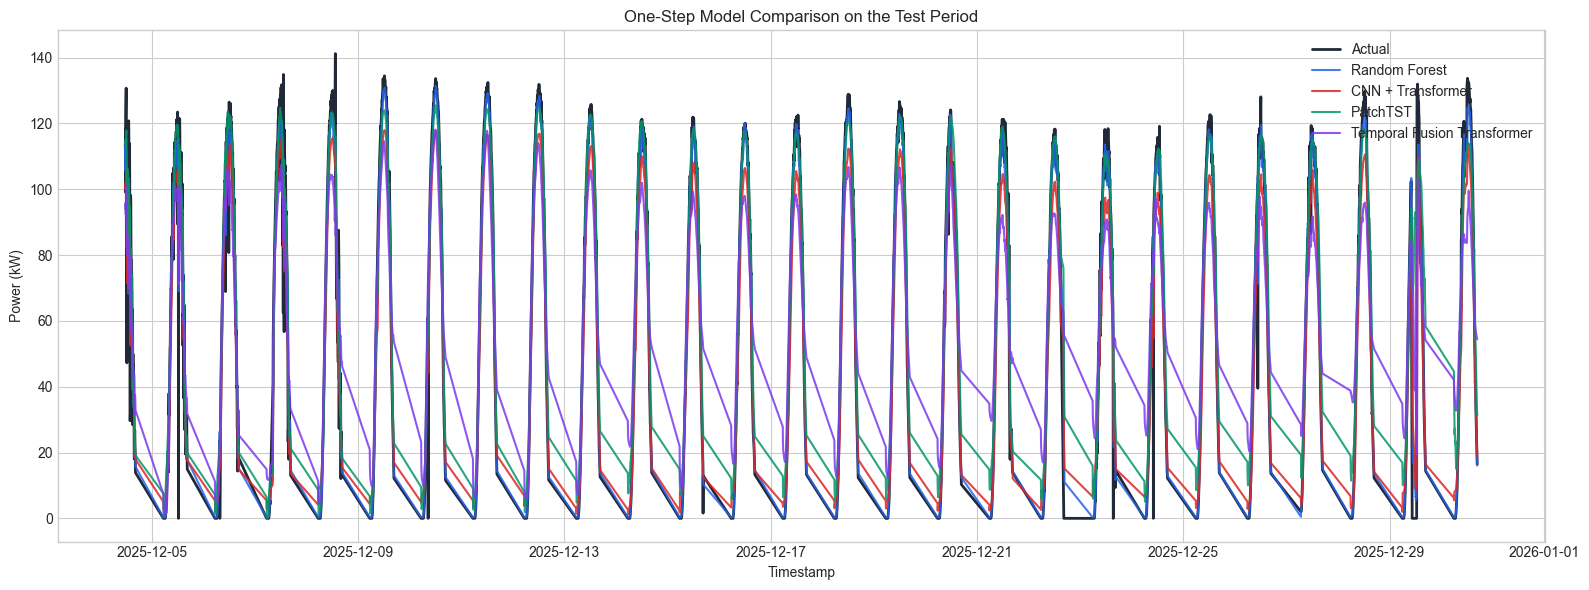

In [16]:
ranked_models = one_step_metrics_df["Model"].tolist()
one_step_plot_df = pd.DataFrame({"timestamp": test_df["timestamp"]})
for model_name in ranked_models:
    one_step_plot_df[model_name] = one_step_predictions[model_name]

plot_model_comparison(
    test_df=test_df,
    prediction_frame=one_step_plot_df[["timestamp"] + ranked_models],
    title="One-Step Model Comparison on the Test Period",
)

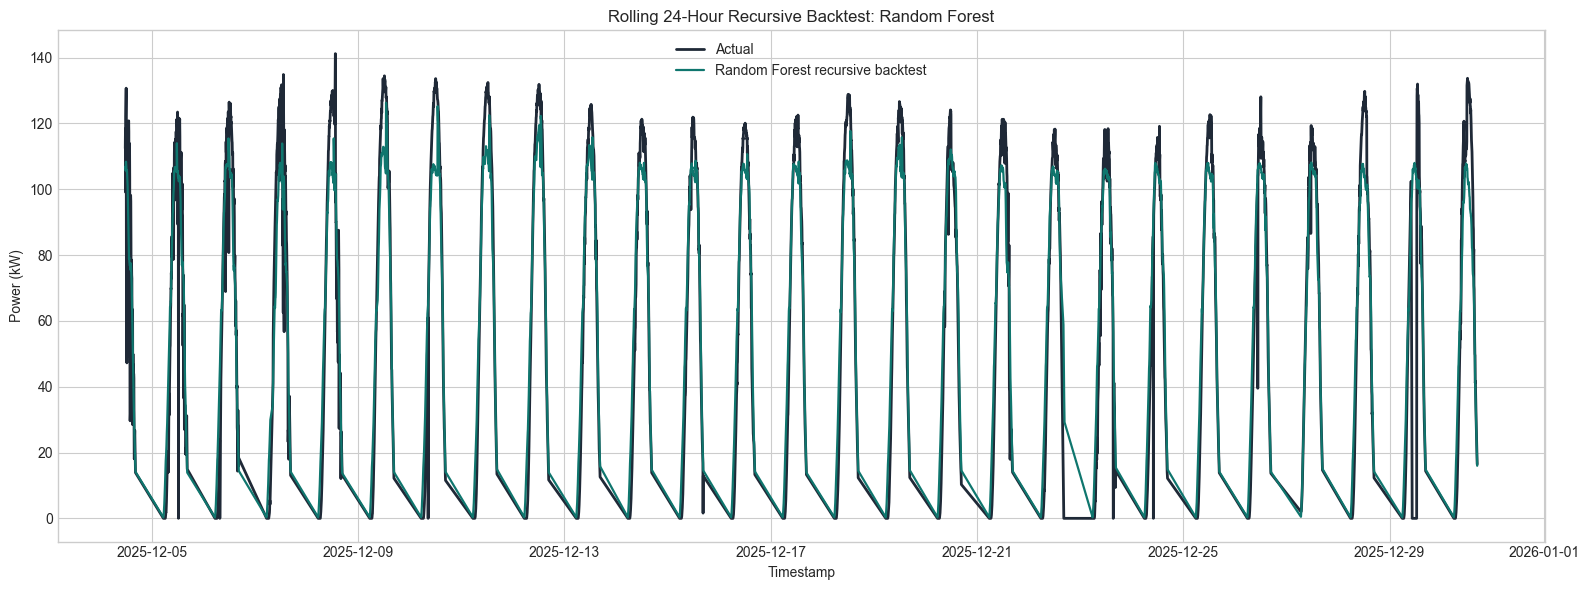

In [26]:
best_recursive_model_name = (
    recursive_metrics_df.loc[recursive_metrics_df["Scope"] == "Daylight only"]
    .sort_values("RMSE")
    .iloc[0]["Model"]
)

plot_recursive_backtest(
    backtest_df=recursive_backtests[best_recursive_model_name],
    model_label=best_recursive_model_name,
)

In [27]:
best_model_name = best_recursive_model_name
print("Best model selected for recursive forecasting:", best_model_name)

history_features = feature_df_full.dropna(subset=feature_columns + ["power_kw"]).copy()
future_weather = get_future_weather(
    latitude=CONFIG["latitude"],
    longitude=CONFIG["longitude"],
    last_timestamp=history_features["timestamp"].max(),
    horizon_steps=FORECAST_STEPS,
    timezone=CONFIG["timezone"],
    historical_weather_5min=weather_5min,
)

if ensemble_definition and best_model_name == ensemble_definition.get("name"):
    member_outputs = {}
    for member_name in ensemble_definition["members"]:
        member_forecast = recursive_forecast(
            model_entry=model_entries[member_name],
            history_features=history_features,
            future_weather=future_weather,
            feature_columns=feature_columns,
            sequence_length=CONFIG["sequence_length"],
        )
        member_forecast["forecast_power_kw"] = apply_affine_calibrator(
            member_forecast["forecast_power_kw"].to_numpy(),
            model_entries[member_name].get("calibrator"),
        )
        member_outputs[member_name] = member_forecast

    base_member = ensemble_definition["members"][0]
    forecast_df = member_outputs[base_member].loc[:, ["timestamp", "ALLSKY_SFC_SW_DWN", "T2M", "CLOUD_AMT", "weather_source"]].copy()
    forecast_df["forecast_power_kw"] = 0.0
    for member_name, weight in ensemble_definition["weights"].items():
        forecast_df["forecast_power_kw"] += float(weight) * member_outputs[member_name]["forecast_power_kw"].to_numpy()
else:
    forecast_df = recursive_forecast(
        model_entry=model_entries[best_model_name],
        history_features=history_features,
        future_weather=future_weather,
        feature_columns=feature_columns,
        sequence_length=CONFIG["sequence_length"],
    )
    forecast_df["forecast_power_kw"] = apply_affine_calibrator(
        forecast_df["forecast_power_kw"].to_numpy(),
        model_entries[best_model_name].get("calibrator"),
    )

print("Future weather source:", future_weather["weather_source"].iloc[0])
print("Future irradiance summary:", future_weather["ALLSKY_SFC_SW_DWN"].describe()[["min", "max", "mean"]].to_dict())
if ensemble_definition and best_model_name == ensemble_definition.get("name"):
    print("Ensemble members and weights:", ensemble_definition["weights"])
forecast_df.head()

Best model selected for recursive forecasting: Random Forest
Future weather source: recent_profile_proxy
Future irradiance summary: {'min': 0.0, 'max': 950.88, 'mean': 282.94496238425927}


,timestamp,forecast_power_kw,ALLSKY_SFC_SW_DWN,T2M,CLOUD_AMT,weather_source
0,2026-04-11 11:55:00,72.442555,864.276667,40.2350,33.14,recent_profile_proxy
1,2026-04-11 12:00:00,75.939649,861.120000,40.3200,33.14,recent_profile_proxy
2,2026-04-11 12:05:00,74.811797,853.310000,40.3625,33.14,recent_profile_proxy
3,2026-04-11 12:10:00,76.568459,845.500000,40.4050,33.14,recent_profile_proxy
4,2026-04-11 12:15:00,75.785165,837.690000,40.4475,33.14,recent_profile_proxy


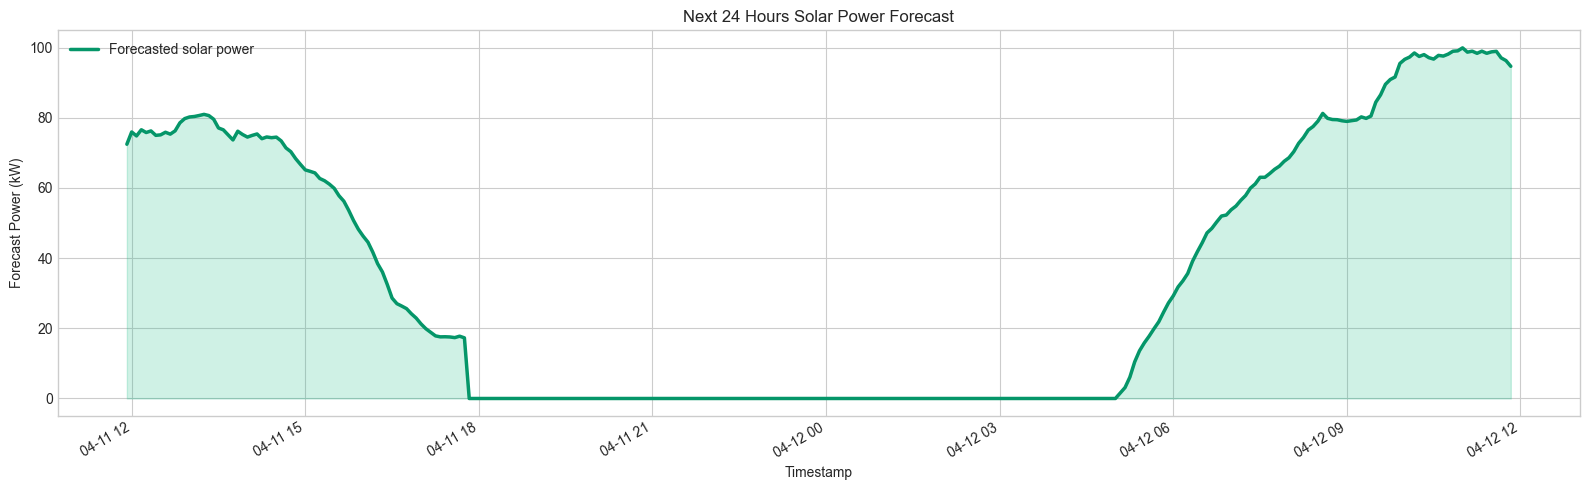

Saved future forecast plot to: output_images_v3/future_forecast_next_24h.png


,timestamp,forecast_power_kw,ALLSKY_SFC_SW_DWN,T2M,CLOUD_AMT,weather_source
283,2026-04-12 11:30:00,98.769624,880.060000,30.06,33.14,recent_profile_proxy
284,2026-04-12 11:35:00,98.913825,876.903333,30.06,33.14,recent_profile_proxy
285,2026-04-12 11:40:00,97.048216,873.746667,30.06,33.14,recent_profile_proxy
286,2026-04-12 11:45:00,96.276335,870.590000,30.06,33.14,recent_profile_proxy
287,2026-04-12 11:50:00,94.646525,867.433333,30.06,33.14,recent_profile_proxy


In [29]:
from pathlib import Path

output_dir = Path("output_images_v3")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "future_forecast_next_24h.png"

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    forecast_df["timestamp"],
    forecast_df["forecast_power_kw"],
    linewidth=2.5,
    color="#059669",
    label="Forecasted solar power",
)
ax.fill_between(
    forecast_df["timestamp"],
    forecast_df["forecast_power_kw"],
    alpha=0.20,
    color="#10b981",
)
ax.set_title("Next 24 Hours Solar Power Forecast")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Forecast Power (kW)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved future forecast plot to: {output_path}")
forecast_df.tail()

## 8. Best-practice recommendations to improve accuracy

1. Replace proxy future weather with a true forecast provider for operational day-ahead deployment.
2. Keep `Gen_Sum` as the default target for plant-level forecasting because it is cleaner than summing noisy meter channels every time.
3. Add domain-specific daylight indicators such as solar zenith angle, sunrise, and sunset if you want even stronger publication-quality baselines.
4. Separate data quality flags for meter outages, inverter clipping, maintenance windows, and partial-day logs instead of treating all zeros as true no-generation.
5. Try direct multi-step forecasting or quantile loss if your research needs uncertainty estimation, not just point prediction.
6. Tune the Random Forest and sequence length with a rolling-origin validation protocol for the final experimental section of your thesis.
7. Compare 5-minute forecasting against an hourly-aggregated version too; many solar forecasting studies report better generalization at hourly cadence.
8. Add more exogenous signals later such as humidity, wind, aerosol, or local cloud observations if your committee expects stronger meteorological modeling depth.

## 9. Interactive Gradio Predictor

Use this interface to select a date and time and predict solar power generation using the best recursive model selected by the notebook (including ensemble if selected).

In [ ]:
try:
    import gradio as gr
except ImportError:
    raise ImportError("Gradio is not installed. Run Cell 3 (setup cell) to install gradio, then rerun this cell.")


GRADIO_FORECAST_CACHE = {}


def _build_gradio_forecast_cache():
    required = [
        "best_model_name",
        "model_entries",
        "feature_df_full",
        "feature_columns",
        "weather_5min",
        "CONFIG",
        "FORECAST_STEPS",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        return None, f"Missing required objects: {missing}. Run Cells 4 to 27 first."

    full_hist = feature_df_full.dropna(subset=feature_columns + ["power_kw"]).copy()
    full_hist = full_hist.sort_values("timestamp").reset_index(drop=True)
    latest_hist_ts = pd.Timestamp(full_hist["timestamp"].max())

    future_weather = get_future_weather(
        latitude=CONFIG["latitude"],
        longitude=CONFIG["longitude"],
        last_timestamp=latest_hist_ts,
        horizon_steps=FORECAST_STEPS,
        timezone=CONFIG["timezone"],
        historical_weather_5min=weather_5min,
    )

    def _apply_cal(preds, calibrator):
        arr = np.asarray(preds, dtype=float)
        if not calibrator:
            return np.clip(arr, 0.0, None)
        slope = float(calibrator.get("slope", 1.0))
        intercept = float(calibrator.get("intercept", 0.0))
        return np.clip(slope * arr + intercept, 0.0, None)

    if "ensemble_definition" in globals() and ensemble_definition and best_model_name == ensemble_definition.get("name"):
        member_outputs = {}
        for member_name in ensemble_definition["members"]:
            member_forecast = recursive_forecast(
                model_entry=model_entries[member_name],
                history_features=full_hist,
                future_weather=future_weather,
                feature_columns=feature_columns,
                sequence_length=CONFIG["sequence_length"],
            )
            member_forecast["forecast_power_kw"] = _apply_cal(
                member_forecast["forecast_power_kw"].to_numpy(),
                model_entries[member_name].get("calibrator"),
            )
            member_outputs[member_name] = member_forecast

        base_member = ensemble_definition["members"][0]
        forecast_df = member_outputs[base_member].copy()
        forecast_df["forecast_power_kw"] = 0.0
        for member_name, weight in ensemble_definition["weights"].items():
            forecast_df["forecast_power_kw"] += float(weight) * member_outputs[member_name]["forecast_power_kw"].to_numpy()
        model_used = f"{best_model_name} with weights {ensemble_definition['weights']}"
    else:
        forecast_df = recursive_forecast(
            model_entry=model_entries[best_model_name],
            history_features=full_hist,
            future_weather=future_weather,
            feature_columns=feature_columns,
            sequence_length=CONFIG["sequence_length"],
        )
        forecast_df["forecast_power_kw"] = _apply_cal(
            forecast_df["forecast_power_kw"].to_numpy(),
            model_entries[best_model_name].get("calibrator"),
        )
        model_used = best_model_name

    cache_key = (str(latest_hist_ts), model_used)
    forecast_df = forecast_df.loc[:, ["timestamp", "forecast_power_kw", "ALLSKY_SFC_SW_DWN", "T2M", "CLOUD_AMT", "weather_source"]].copy()
    GRADIO_FORECAST_CACHE[cache_key] = forecast_df
    return forecast_df, None


def _predict_with_selected_model_at_timestamp(selected_dt):
    required = [
        "best_model_name",
        "model_entries",
        "feature_df_full",
        "feature_columns",
        "weather_5min",
        "CONFIG",
        "STEPS_PER_HOUR",
        "FORECAST_STEPS",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        return f"Missing required objects: {missing}. Run Cells 4 to 27 first.", None

    if selected_dt is None:
        return "Please choose a valid date and time.", None

    target_ts = pd.Timestamp(selected_dt).floor(CONFIG["frequency"])

    full_hist = feature_df_full.dropna(subset=feature_columns + ["power_kw"]).copy()
    full_hist = full_hist.sort_values("timestamp").reset_index(drop=True)
    latest_hist_ts = pd.Timestamp(full_hist["timestamp"].max())

    if target_ts <= latest_hist_ts:
        nearest_idx = (full_hist["timestamp"] - target_ts).abs().idxmin()
        observed_ts = pd.Timestamp(full_hist.loc[nearest_idx, "timestamp"])
        observed_kw = float(full_hist.loc[nearest_idx, "power_kw"])
        msg = (
            f"Selected time is within historical data. Returning observed power at {observed_ts}: "
            f"{observed_kw:.3f} kW"
        )
        return msg, observed_kw

    horizon_steps = int((target_ts - latest_hist_ts) / pd.Timedelta(CONFIG["frequency"]))
    if horizon_steps <= 0:
        return "Could not compute a valid forecast horizon from the selected timestamp.", None

    cache_key = None
    if horizon_steps <= FORECAST_STEPS:
        cached_forecast = None
        for key, cached_df in GRADIO_FORECAST_CACHE.items():
            if selected_dt is not None and pd.Timestamp(selected_dt).floor(CONFIG["frequency"]) in set(cached_df["timestamp"]):
                cached_forecast = cached_df
                cache_key = key
                break
        if cached_forecast is None:
            cached_forecast, _ = _build_gradio_forecast_cache()
        if cached_forecast is not None and not cached_forecast.empty:
            match_ts = pd.Timestamp(selected_dt).floor(CONFIG["frequency"])
            match_row = cached_forecast.loc[cached_forecast["timestamp"] == match_ts]
            if not match_row.empty:
                predicted_kw = float(match_row.iloc[0]["forecast_power_kw"])
                weather_source = str(match_row.iloc[0].get("weather_source", "unknown"))
                msg = (
                    f"Predicted solar power at {match_ts}: {predicted_kw:.3f} kW | "
                    f"Model: {best_model_name} | Weather source: {weather_source} | "
                    f"Mode: cached lookup"
                )
                return msg, predicted_kw

    future_weather = get_future_weather(
        latitude=CONFIG["latitude"],
        longitude=CONFIG["longitude"],
        last_timestamp=latest_hist_ts,
        horizon_steps=horizon_steps,
        timezone=CONFIG["timezone"],
        historical_weather_5min=weather_5min,
    )

    def _apply_cal(preds, calibrator):
        arr = np.asarray(preds, dtype=float)
        if not calibrator:
            return np.clip(arr, 0.0, None)
        slope = float(calibrator.get("slope", 1.0))
        intercept = float(calibrator.get("intercept", 0.0))
        return np.clip(slope * arr + intercept, 0.0, None)

    if "ensemble_definition" in globals() and ensemble_definition and best_model_name == ensemble_definition.get("name"):
        member_outputs = {}
        for member_name in ensemble_definition["members"]:
            member_forecast = recursive_forecast(
                model_entry=model_entries[member_name],
                history_features=full_hist,
                future_weather=future_weather,
                feature_columns=feature_columns,
                sequence_length=CONFIG["sequence_length"],
            )
            member_forecast["forecast_power_kw"] = _apply_cal(
                member_forecast["forecast_power_kw"].to_numpy(),
                model_entries[member_name].get("calibrator"),
            )
            member_outputs[member_name] = member_forecast

        base_member = ensemble_definition["members"][0]
        forecast_df = member_outputs[base_member].copy()
        forecast_df["forecast_power_kw"] = 0.0
        for member_name, weight in ensemble_definition["weights"].items():
            forecast_df["forecast_power_kw"] += float(weight) * member_outputs[member_name]["forecast_power_kw"].to_numpy()
        model_used = f"{best_model_name} with weights {ensemble_definition['weights']}"
    else:
        forecast_df = recursive_forecast(
            model_entry=model_entries[best_model_name],
            history_features=full_hist,
            future_weather=future_weather,
            feature_columns=feature_columns,
            sequence_length=CONFIG["sequence_length"],
        )
        forecast_df["forecast_power_kw"] = _apply_cal(
            forecast_df["forecast_power_kw"].to_numpy(),
            model_entries[best_model_name].get("calibrator"),
        )
        model_used = best_model_name

    if forecast_df.empty:
        return "Forecast generation failed for the selected timestamp.", None

    predicted_kw = float(forecast_df.iloc[-1]["forecast_power_kw"])
    weather_source = str(forecast_df.iloc[-1].get("weather_source", "unknown"))
    msg = (
        f"Predicted solar power at {target_ts}: {predicted_kw:.3f} kW | "
        f"Model: {model_used} | Weather source: {weather_source}"
    )
    return msg, predicted_kw


with gr.Blocks(title="Solar Power Time Picker Predictor") as solar_power_app:
    gr.Markdown("# Solar Power Predictor")
    gr.Markdown(
        "Pick a date and time. For future timestamps, the trained model forecasts solar generation. "
        "For historical timestamps, the nearest observed value is returned."
    )

    with gr.Row():
        dt_input = gr.DateTime(label="Select Date and Time", type="datetime")

    predict_btn = gr.Button("Predict Solar Power", variant="primary")
    status_out = gr.Textbox(label="Prediction Details")
    power_out = gr.Number(label="Predicted/Observed Solar Power (kW)")

    predict_btn.click(
        fn=_predict_with_selected_model_at_timestamp,
        inputs=[dt_input],
        outputs=[status_out, power_out],
    )

_build_gradio_forecast_cache()
solar_power_app

Gradio Blocks instance: 1 backend functions
-------------------------------------------
fn_index=0
 inputs:
 |-<gradio.components.datetime.DateTime object at 0x134b0a350>
 outputs:
 |-<gradio.components.textbox.Textbox object at 0x134b0a710>
 |-<gradio.components.number.Number object at 0x134b0a850>

In [33]:
solar_power_app.launch(inbrowser=True, share=False, prevent_thread_lock=True)

NameError: name 'solar_power_app' is not defined

In [19]:

import os
import json
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
models_dir = Path("./models")
models_dir.mkdir(exist_ok=True)

print("Saving all trained models...")

# Dictionary to store metadata for all saved models
model_manifest = {
    "saved_models": {},
    "ensemble_definition": ensemble_definition if "ensemble_definition" in globals() else {},
    "config": {
        "sequence_length": CONFIG.get("sequence_length") if "CONFIG" in globals() else None,
        "feature_columns": feature_columns if "feature_columns" in globals() else [],
    }
}

# Save each model
for model_name, model_entry in model_entries.items():
    print(f"\nSaving {model_name}...")
    
    # Create subdirectory for this model
    model_subdir = models_dir / model_name.replace(" ", "_").replace("+", "plus")
    model_subdir.mkdir(exist_ok=True)
    
    # Save the main model
    model_file = model_subdir / "model.pkl"
    joblib.dump(model_entry["model"], model_file)
    
    # Save calibrator if present
    if "calibrator" in model_entry and model_entry["calibrator"]:
        calibrator_file = model_subdir / "calibrator.json"
        with open(calibrator_file, "w") as f:
            json.dump(model_entry["calibrator"], f, indent=2)
    
    # Save metadata
    metadata = {
        "name": model_name,
        "family": model_entry.get("family"),
        "model_type": type(model_entry["model"]).__name__,
        "has_calibrator": "calibrator" in model_entry and model_entry["calibrator"] is not None,
        "saved_path": str(model_subdir),
    }
    
    # Add to manifest
    model_manifest["saved_models"][model_name] = metadata
    
    print(f"  ✓ Saved to {model_subdir}")

# Save sequence bundle scalers if available
try:
    if "sequence_bundle" in globals() and sequence_bundle is not None and hasattr(sequence_bundle, "tree_scaler"):
        scalers_dir = models_dir / "scalers"
        scalers_dir.mkdir(exist_ok=True)
        
        # Save tree scaler
        tree_scaler_file = scalers_dir / "tree_scaler.pkl"
        joblib.dump(sequence_bundle.tree_scaler, tree_scaler_file)
        
        # Save sequence scaler if available
        if hasattr(sequence_bundle, "sequence_scaler") and sequence_bundle.sequence_scaler:
            seq_scaler_file = scalers_dir / "sequence_scaler.pkl"
            joblib.dump(sequence_bundle.sequence_scaler, seq_scaler_file)
        
        model_manifest["scalers_saved"] = True
        print(f"\n✓ Saved scalers to {scalers_dir}")
except Exception as e:
    print(f"Warning: Could not save scalers: {e}")

# Save manifest
manifest_file = models_dir / "manifest.json"
with open(manifest_file, "w") as f:
    json.dump(model_manifest, f, indent=2)

print(f"\n✓ Manifest saved to {manifest_file}")
print(f"\n✅ All models saved successfully in: {models_dir.absolute()}")
print(f"Total models saved: {len(model_manifest['saved_models'])}")


Saving all trained models...

Saving Random Forest...
  ✓ Saved to models/Random_Forest

Saving CNN + LSTM...
  ✓ Saved to models/CNN_plus_LSTM

Saving PatchTST...
  ✓ Saved to models/PatchTST

Saving Temporal Fusion Transformer...
  ✓ Saved to models/Temporal_Fusion_Transformer

Saving CNN + Transformer...
  ✓ Saved to models/CNN_plus_Transformer

✓ Manifest saved to models/manifest.json

✅ All models saved successfully in: /Users/rewat/Downloads/Instantaneous copy/models
Total models saved: 5


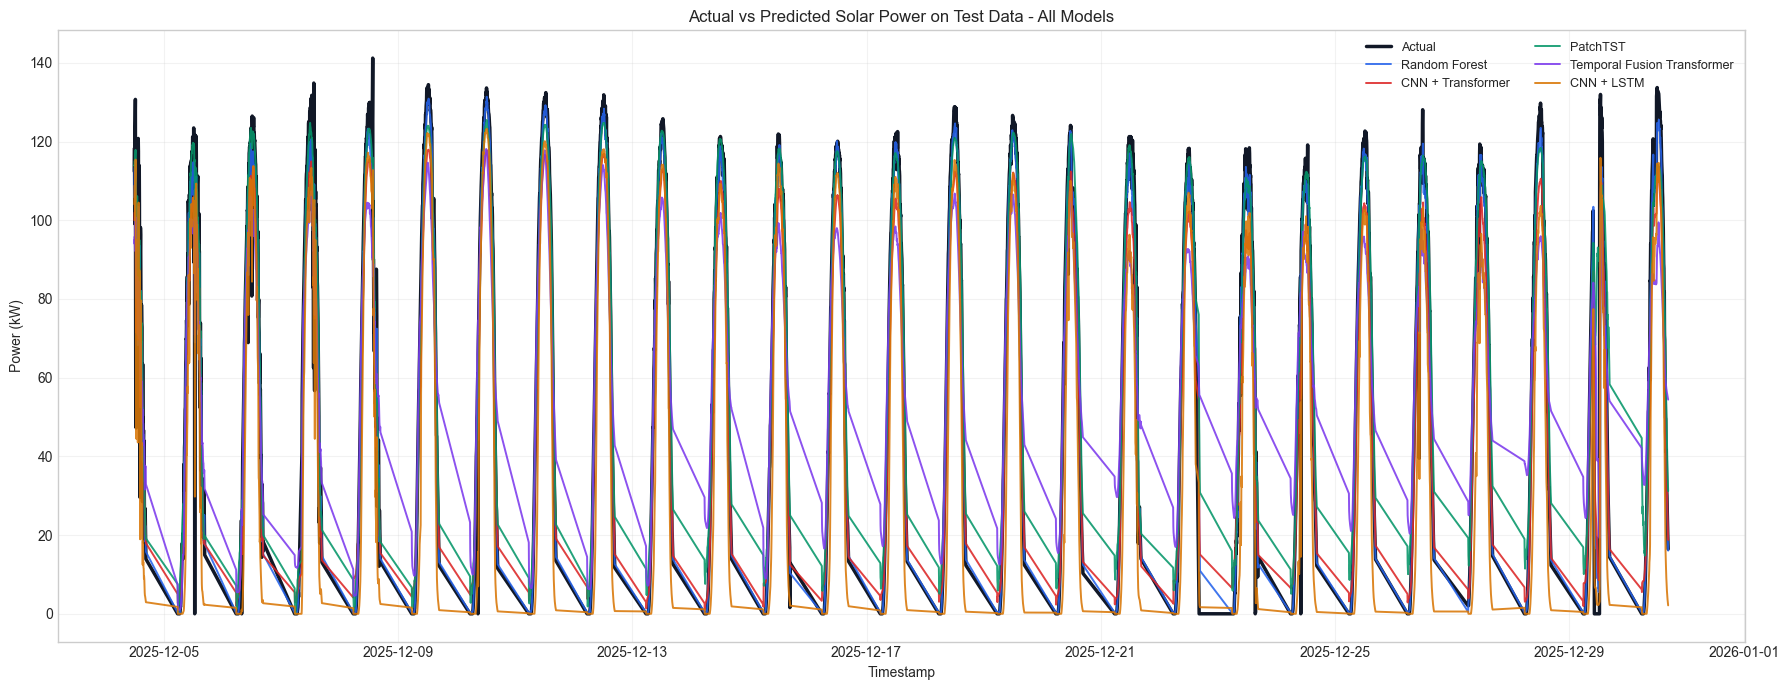

Saved comparison plot to: output_images_v3/actual_vs_predicted_all_models.png


In [22]:
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("output_images_v3")
output_dir.mkdir(exist_ok=True)

all_model_names = one_step_metrics_df["Model"].tolist()
comparison_frame = pd.DataFrame({"timestamp": test_df["timestamp"]})
for model_name in all_model_names:
    comparison_frame[model_name] = one_step_predictions[model_name]

plt.figure(figsize=(18, 7))
plt.plot(test_df["timestamp"], test_df["power_kw"], label="Actual", linewidth=2.5, color="#111827")
colors = ["#2563eb", "#dc2626", "#059669", "#7c3aed", "#d97706", "#0f766e"]
for idx, model_name in enumerate(all_model_names):
    plt.plot(
        comparison_frame["timestamp"],
        comparison_frame[model_name],
        label=model_name,
        linewidth=1.4,
        alpha=0.88,
        color=colors[idx % len(colors)],
    )

plt.title("Actual vs Predicted Solar Power on Test Data - All Models")
plt.xlabel("Timestamp")
plt.ylabel("Power (kW)")
plt.legend(loc="upper right", ncol=2, fontsize=9)
plt.grid(True, alpha=0.25)
plt.tight_layout()
output_path = output_dir / "actual_vs_predicted_all_models.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved comparison plot to: {output_path}")

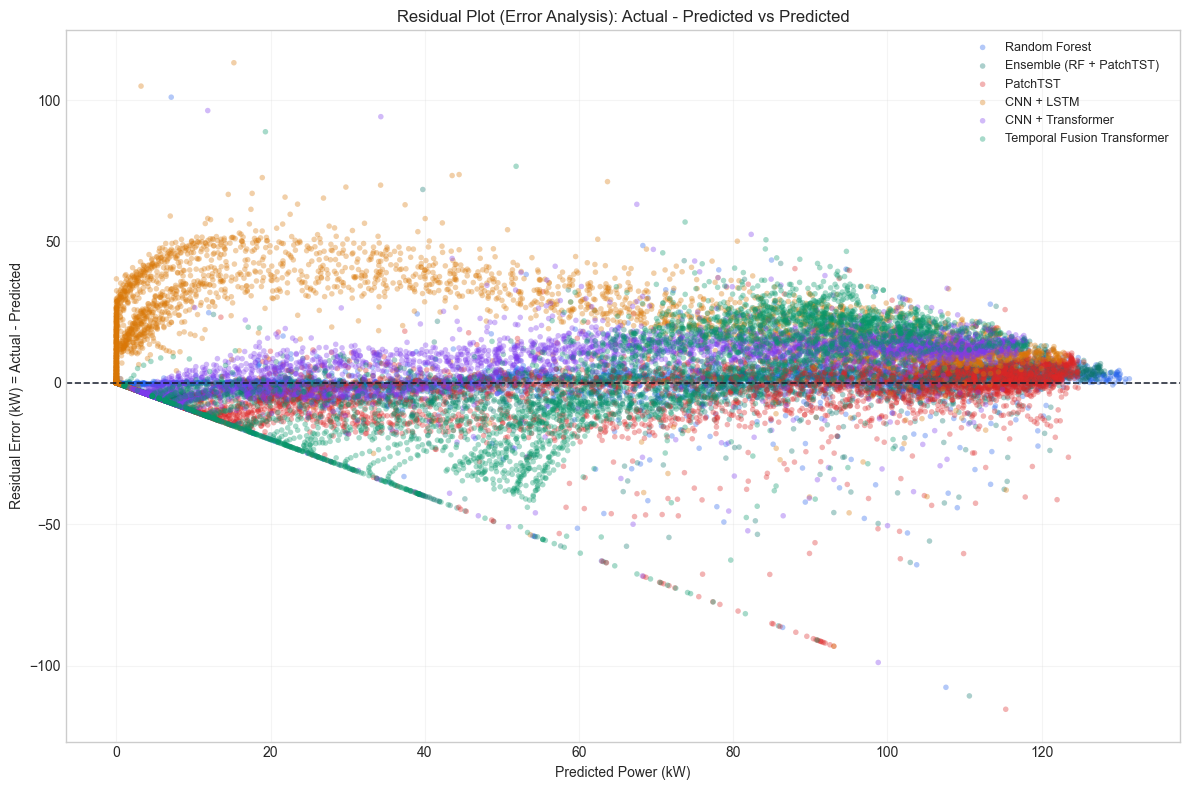

Saved residual plot to: output_images_v3/residual_plot_error_analysis.png


In [16]:
from pathlib import Path

output_dir = Path("output_images_v3")
output_dir.mkdir(exist_ok=True)

model_names = [
    "Random Forest",
    "Ensemble (RF + PatchTST)",
    "PatchTST",
    "CNN + LSTM",
    "CNN + Transformer",
    "Temporal Fusion Transformer",
]

actual = test_df["power_kw"].to_numpy()

# Build ensemble one-step prediction if not already present in one_step_predictions.
if "Ensemble (RF + PatchTST)" not in one_step_predictions and ensemble_definition:
    members = ensemble_definition["members"]
    weights = ensemble_definition["weights"]
    ensemble_pred = sum(float(weights[m]) * one_step_predictions[m] for m in members)
    one_step_predictions["Ensemble (RF + PatchTST)"] = np.asarray(ensemble_pred)

plt.figure(figsize=(12, 8))
palette = {
    "Random Forest": "#2563eb",
    "Ensemble (RF + PatchTST)": "#0f766e",
    "PatchTST": "#dc2626",
    "CNN + LSTM": "#d97706",
    "CNN + Transformer": "#7c3aed",
    "Temporal Fusion Transformer": "#059669",
}

for model_name in model_names:
    if model_name not in one_step_predictions:
        continue
    predicted = np.asarray(one_step_predictions[model_name])
    residual = actual - predicted
    plt.scatter(
        predicted,
        residual,
        s=16,
        alpha=0.35,
        color=palette.get(model_name, None),
        label=model_name,
        edgecolors="none",
    )

plt.axhline(0, color="#111827", linestyle="--", linewidth=1.2, alpha=0.9)
plt.title("Residual Plot (Error Analysis): Actual - Predicted vs Predicted")
plt.xlabel("Predicted Power (kW)")
plt.ylabel("Residual Error (kW) = Actual - Predicted")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()

output_path = output_dir / "residual_plot_error_analysis.png"
plt.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved residual plot to: {output_path}")

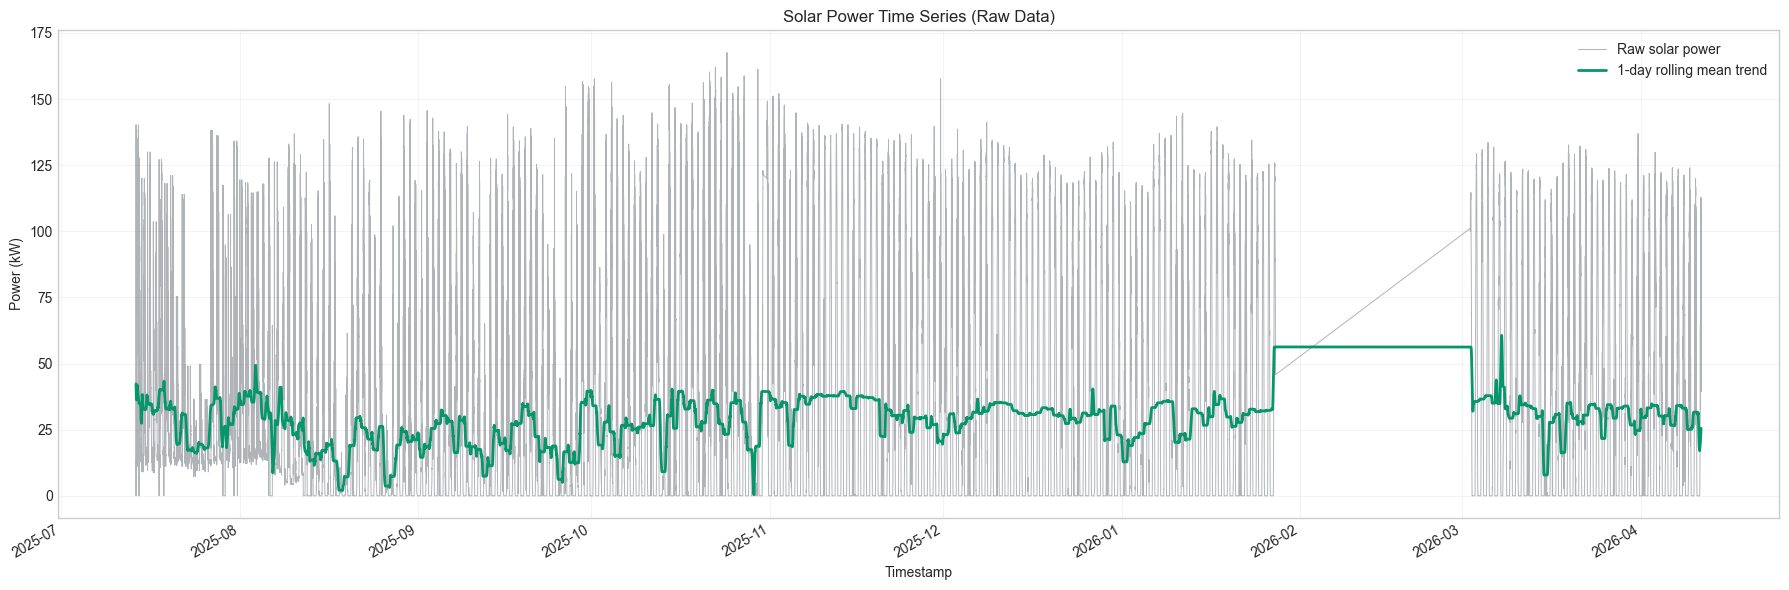

Saved raw time series plot to: output_images_v3/raw_time_series_plot.png


In [17]:
from pathlib import Path

output_dir = Path("output_images_v3")
output_dir.mkdir(exist_ok=True)

# Raw solar power time series with a rolling trend line to show daily patterns and long-term drift.
raw_plot_df = solar_df.loc[:, ["timestamp", "power_kw"]].copy().sort_values("timestamp")
raw_plot_df["trend_1d"] = raw_plot_df["power_kw"].rolling(window=288, min_periods=1, center=True).mean()

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(
    raw_plot_df["timestamp"],
    raw_plot_df["power_kw"],
    color="#1f2937",
    linewidth=0.7,
    alpha=0.35,
    label="Raw solar power",
)
ax.plot(
    raw_plot_df["timestamp"],
    raw_plot_df["trend_1d"],
    color="#059669",
    linewidth=2.0,
    label="1-day rolling mean trend",
)
ax.set_title("Solar Power Time Series (Raw Data)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Power (kW)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()

output_path = output_dir / "raw_time_series_plot.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved raw time series plot to: {output_path}")

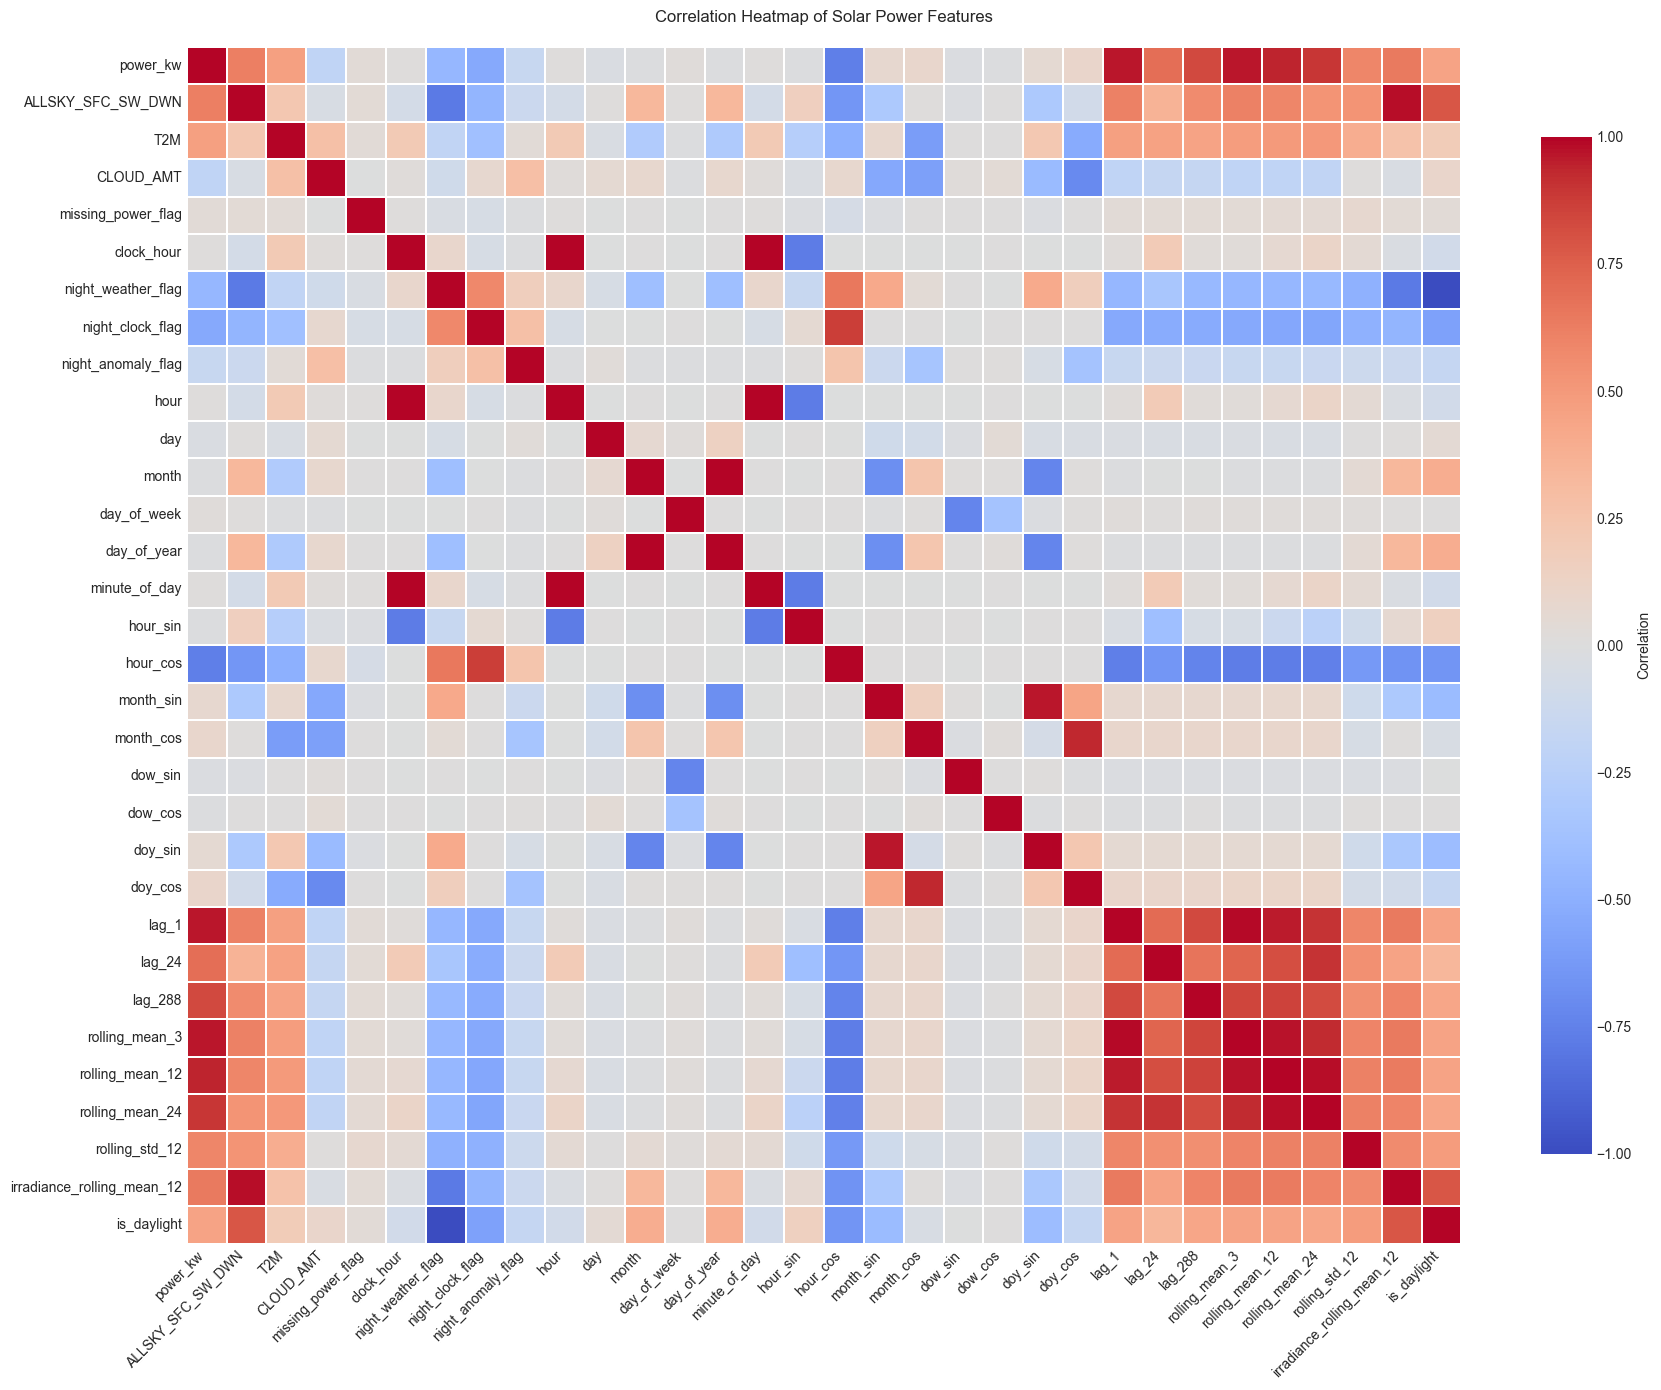

Saved correlation heatmap to: output_images_v3/correlation_heatmap.png


In [9]:
import seaborn as sns
from pathlib import Path

output_dir = Path("output_images_v3")
output_dir.mkdir(exist_ok=True)

# Prefer the full engineered feature table; fall back to the merged raw table if needed.
heatmap_source = feature_df_full.copy() if "feature_df_full" in globals() else merged_df.copy()

if "timestamp" in heatmap_source.columns:
    heatmap_source = heatmap_source.drop(columns=["timestamp"])

numeric_df = heatmap_source.select_dtypes(include=["number"]).copy()

# Limit to a readable set of numeric columns while keeping the core physical features visible.
priority_columns = [
    "power_kw",
    "ALLSKY_SFC_SW_DWN",
    "T2M",
    "CLOUD_AMT",
]
selected_columns = [col for col in priority_columns if col in numeric_df.columns]
selected_columns.extend([col for col in numeric_df.columns if col not in selected_columns])
selected_df = numeric_df.loc[:, selected_columns]

corr = selected_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
)
ax.set_title("Correlation Heatmap of Solar Power Features", pad=18)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

output_path = output_dir / "correlation_heatmap.png"
fig.savefig(output_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved correlation heatmap to: {output_path}")